# MoE Routing & Functional Analysis: English Models
This notebook analyzes English models to determine whether MoE routing decisions reflect age-linked acoustic specialization (RQ2).


## Routing Analysis Roadmap
This notebook is structured to answer the questions in Section Routing Analysis:
- Data collection: how routing distributions are recorded per layer and group.
- Metrics: routing distribution, expert load, and JSD per layer.
- Age analysis within language: adult vs child routing in English.
- Domain control: LibriSpeech vs MyST vs YODAS (all English).
- RQ2 summary plots: divergence curves, peak-layer load, correlations, domain control.


## Setup & Imports


In [54]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from statsmodels.stats.multitest import multipletests

import nemo
import nemo.collections.asr as nemo_asr

K_TOP = 2

print("Analysis dependencies loaded.")

Analysis dependencies loaded.


## Model & Data Configuration


In [55]:
MODEL_DIR = "/lp-dev/amelia/inclusive-asr-moe/final_weights"

MODELS = {
    "baseline_dense": f"{MODEL_DIR}/en_adult_fastconformer.nemo",
    "baseline_dense_child": f"{MODEL_DIR}/en_child_fastconformer.nemo",
    "adult_moe": f"{MODEL_DIR}/en_adult_moe.nemo",
    "child_moe_lb_on": f"{MODEL_DIR}/en_child_moe_lb_on.nemo",
    "child_moe_lb_off": f"{MODEL_DIR}/en_child_moe_lb_off.nemo"
}

TEST_MANIFESTS = {
    "adult": "/data/librispeech_nemo/test_clean.json",
    "child": "/lp-dev/amelia/data/myst/test.json"
}

FEATURE_CACHE = "english_acoustic_features.csv"

## Data Collection (External Script)
Routing extraction is performed by a separate script that writes cached CSVs.
This notebook is analysis-only and reads the cached outputs.

Run the extraction script:
- scripts/experiments/routing_analysis/extract_routing.py

Expected outputs in ROUTING_CACHE_DIR:
- {model_name}_routing.csv
- domain_control_routing.csv (optional)

In [56]:
ROUTING_CACHE_DIR = "/lp-dev/amelia/inclusive-asr-moe/routing_outputs_en"
os.makedirs(ROUTING_CACHE_DIR, exist_ok=True)

MOE_MODELS_TO_RUN = {
    "adult_moe":        MODELS["adult_moe"],
    "child_moe_lb_on":  MODELS["child_moe_lb_on"],
    "child_moe_lb_off": MODELS["child_moe_lb_off"],
}

all_routing = {}

for model_name in MOE_MODELS_TO_RUN.keys():
    cache_path = f"{ROUTING_CACHE_DIR}/{model_name}_routing.csv"
    if not os.path.exists(cache_path):
        raise FileNotFoundError(
            f"Missing cached routing file for {model_name}: {cache_path}\n"
            "Run scripts/experiments/routing_analysis/extract_routing.py to generate it."
        )
    print(f"Loading cached routing for {model_name}")
    all_routing[model_name] = pd.read_csv(cache_path)

sample_df = next(iter(all_routing.values()))
if not any(c.startswith("expert_") and c.endswith("_prob") for c in sample_df.columns):
    raise ValueError(
        "Expected columns like expert_0_prob in cached routing files."
    )

# Validate expert column sums per layer: ~K_TOP (top-k counts) or ~1.0 (softmax)
expert_cols = [c for c in sample_df.columns if c.startswith("expert_") and c.endswith("_prob")]
layer0 = sample_df[sample_df["layer_idx"] == 0]
if not layer0.empty:
    col_sum = layer0[expert_cols].mean(axis=0).sum()
    if not (np.isclose(col_sum, K_TOP, atol=0.1) or np.isclose(col_sum, 1.0, atol=0.1)):
        raise ValueError(
            f"Expert columns sum to {col_sum:.3f}; expected ~{K_TOP} (top-k) or ~1.0 (softmax)."
        )
    print(f"Expert columns sum to {col_sum:.3f} per frame (expected ~{K_TOP} or ~1.0)")

print("Cached routing loaded for all models.")

Loading cached routing for adult_moe
Loading cached routing for child_moe_lb_on
Loading cached routing for child_moe_lb_off
Expert columns sum to 1.000 per frame (expected ~2 or ~1.0)
Cached routing loaded for all models.


## Metrics and Plots
We report routing distribution $p_e^{(g)}$, expert load $\ell_e^{(g)} = k \cdot p_e^{(g)}$, and JSD per layer.
JSD uses all available data; statistical significance is computed on duration-matched subsamples only.
All plots are saved to disk and shown inline.

In [57]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2_contingency

BOOTSTRAP_N = 1000
BOOTSTRAP_SEED = 42

def _parse_expert_index(col):
    parts = col.split("_")
    try:
        return int(parts[1])
    except (IndexError, ValueError):
        return 0

def _expert_cols(df):
    cols = [c for c in df.columns if c.startswith("expert_") and c.endswith("_prob")]
    return sorted(cols, key=_parse_expert_index)

def _duration_col(df):
    if "duration_sec" in df.columns:
        return df["duration_sec"]
    if "duration" in df.columns:
        return df["duration"]
    return pd.Series([np.nan] * len(df), index=df.index)

def subsample_by_duration(df, target_seconds, seed=42):
    if target_seconds <= 0 or df.empty:
        return df.iloc[0:0]
    df = df.copy()
    df["_duration_sec"] = _duration_col(df)
    df = df[df["_duration_sec"].notna() & (df["_duration_sec"] > 0)]
    if df.empty:
        return df
    df = df.sample(frac=1, random_state=seed)
    cum = df["_duration_sec"].cumsum()
    selected = df[cum <= target_seconds]
    if len(selected) < len(df) and len(selected) > 0:
        selected = pd.concat([selected, df.iloc[[len(selected)]]])
    elif len(selected) == 0:
        selected = df.iloc[[0]]
    return selected.drop(columns=["_duration_sec"])

def _mean_probs(df, expert_cols):
    if df.empty:
        return None
    probs = df[expert_cols].mean(axis=0).values
    total = probs.sum()
    return probs / total if total > 0 else None

def _jsd_divergence(p, q):
    dist = jensenshannon(p, q, base=2)
    return float(dist * dist)

def _top1_counts_from_df(df, n_experts):
    if "top1_expert" in df.columns:
        return df["top1_expert"].value_counts().reindex(range(n_experts), fill_value=0).values
    return np.zeros(n_experts)

def chi2_significance_duration_matched(df_a, df_b, n_experts, seed=42):
    dur_a = _duration_col(df_a).sum()
    dur_b = _duration_col(df_b).sum()
    if not np.isfinite(dur_a) or not np.isfinite(dur_b):
        return np.nan, np.nan, np.nan, False
    target = min(float(dur_a), float(dur_b))
    sub_a = subsample_by_duration(df_a, target_seconds=target, seed=seed)
    sub_b = subsample_by_duration(df_b, target_seconds=target, seed=seed + 1)
    if sub_a.empty or sub_b.empty:
        return np.nan, np.nan, np.nan, False
    adult_counts = _top1_counts_from_df(sub_a, n_experts)
    child_counts = _top1_counts_from_df(sub_b, n_experts)
    try:
        chi2_stat, p_val, dof, _ = chi2_contingency(np.array([adult_counts, child_counts]))
        return chi2_stat, p_val, dof, bool(p_val < 0.05)
    except ValueError:
        return np.nan, np.nan, np.nan, False

def mean_probs_by_group(df, group_cols, n_layers=17):
    expert_cols = _expert_cols(df)
    grouped = {}
    for key, df_g in df.groupby(list(group_cols)):
        key = key if isinstance(key, tuple) else (key,)
        layer_means = []
        for layer in range(n_layers):
            df_l = df_g[df_g["layer_idx"] == layer]
            probs = _mean_probs(df_l, expert_cols)
            if probs is None:
                layer_means.append(np.full(len(expert_cols), np.nan))
                continue
            layer_means.append(probs)
        grouped[key] = np.stack(layer_means)
    return grouped, expert_cols

def plot_expert_load_heatmaps(df, group_col, title_prefix, save_path, n_layers=17):
    grouped, expert_cols = mean_probs_by_group(df, (group_col,), n_layers=n_layers)
    n_experts = len(expert_cols)
    groups = sorted(grouped.keys())
    fig, axes = plt.subplots(1, len(groups), figsize=(4.5 * len(groups), 6), sharey=True)
    if len(groups) == 1:
        axes = [axes]
    for ax, key in zip(axes, groups):
        probs = grouped[key]
        load = K_TOP * probs
        sns.heatmap(
            load, ax=ax, cmap="viridis", vmin=0, vmax=K_TOP,
            xticklabels=[f"E{e}" for e in range(n_experts)],
            yticklabels=range(n_layers),
            cbar=True, cbar_kws={"label": "expert load (avg per frame)"},
        )
        ax.set_title(f"{title_prefix} | {group_col}={key[0]}")
        ax.set_xlabel("Expert")
    axes[0].set_ylabel("Layer")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def jsd_per_layer(df_a, df_b, n_layers=17):
    expert_cols = _expert_cols(df_a)
    vals = []
    for layer in range(n_layers):
        a = _mean_probs(df_a[df_a["layer_idx"] == layer], expert_cols)
        b = _mean_probs(df_b[df_b["layer_idx"] == layer], expert_cols)
        if a is None or b is None:
            vals.append(np.nan)
            continue
        vals.append(_jsd_divergence(a, b))
    return vals

def bootstrap_jsd_per_layer(df_a, df_b, n_layers=17,
                            n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED):
    expert_cols = _expert_cols(df_a)
    means = np.full(n_layers, np.nan)
    ci_low = np.full(n_layers, np.nan)
    ci_high = np.full(n_layers, np.nan)

    for layer in range(n_layers):
        df_a_l = df_a[df_a["layer_idx"] == layer]
        df_b_l = df_b[df_b["layer_idx"] == layer]
        if df_a_l.empty or df_b_l.empty:
            continue

        dur_a = _duration_col(df_a_l).sum()
        dur_b = _duration_col(df_b_l).sum()
        if not np.isfinite(dur_a) or not np.isfinite(dur_b):
            continue
        target = min(float(dur_a), float(dur_b))

        matched_a = subsample_by_duration(df_a_l, target_seconds=target, seed=seed)
        matched_b = subsample_by_duration(df_b_l, target_seconds=target, seed=seed + 1)
        if matched_a.empty or matched_b.empty:
            continue

        boot_vals = []
        for b in range(n_boot):
            sample_a = matched_a.sample(n=len(matched_a), replace=True, random_state=seed + b * 2)
            sample_b = matched_b.sample(n=len(matched_b), replace=True, random_state=seed + b * 2 + 1)
            a = _mean_probs(sample_a, expert_cols)
            b_probs = _mean_probs(sample_b, expert_cols)
            if a is None or b_probs is None:
                continue
            boot_vals.append(_jsd_divergence(a, b_probs))

        if boot_vals:
            vals = np.array(boot_vals)
            means[layer] = float(np.mean(vals))
            ci_low[layer] = float(np.percentile(vals, 2.5))
            ci_high[layer] = float(np.percentile(vals, 97.5))

    return means, ci_low, ci_high

def plot_jsd_by_group(df, group_col, group_a, group_b, title, save_path, n_layers=17):
    df_a = df[df[group_col] == group_a]
    df_b = df[df[group_col] == group_b]
    mean_vals, ci_low, ci_high = bootstrap_jsd_per_layer(
        df_a, df_b, n_layers=n_layers
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(n_layers)
    ax.plot(x, mean_vals, marker="o", label="mean")
    ax.fill_between(x, ci_low, ci_high, alpha=0.2, label="95% CI")
    ax.set_xticks(range(n_layers))
    ax.set_xticklabels([f"L{i}" for i in range(n_layers)])
    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD divergence (bits)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return mean_vals, ci_low, ci_high

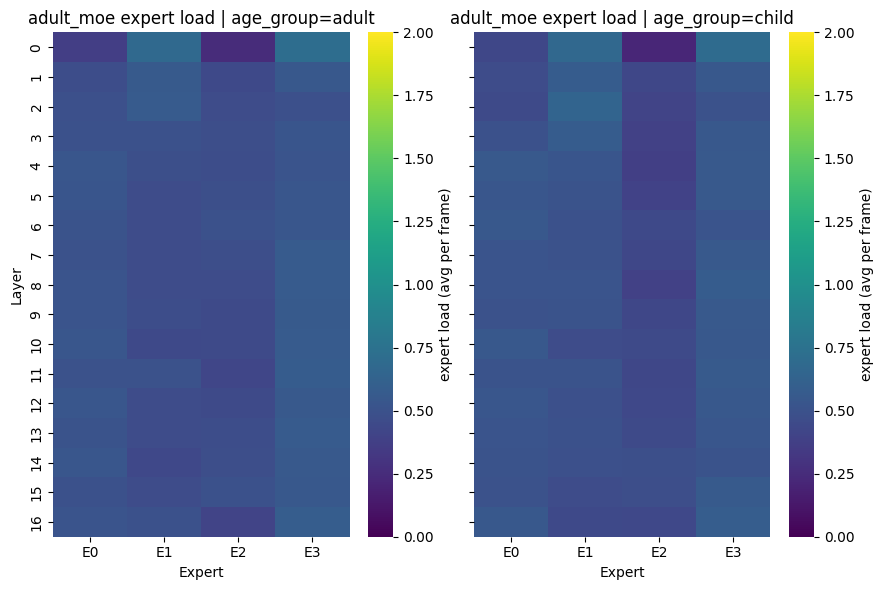

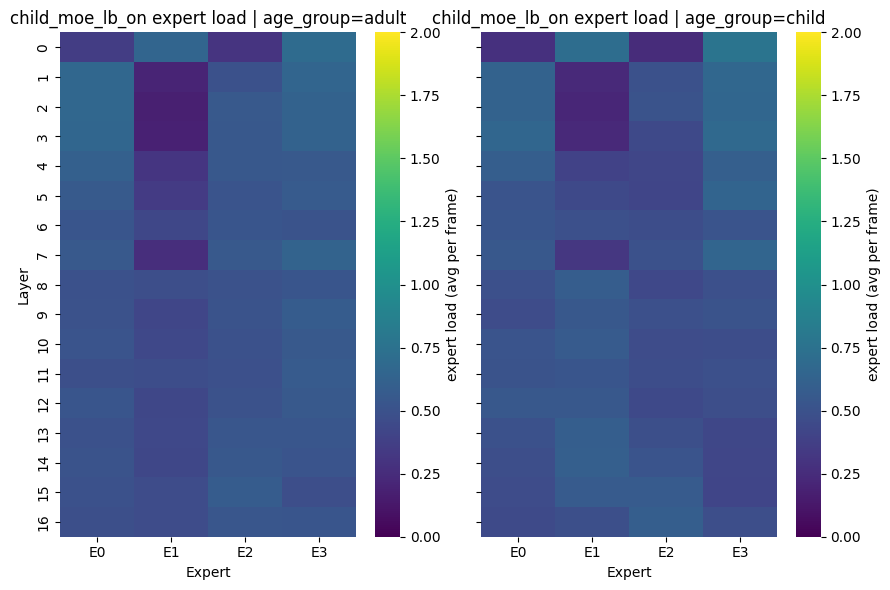

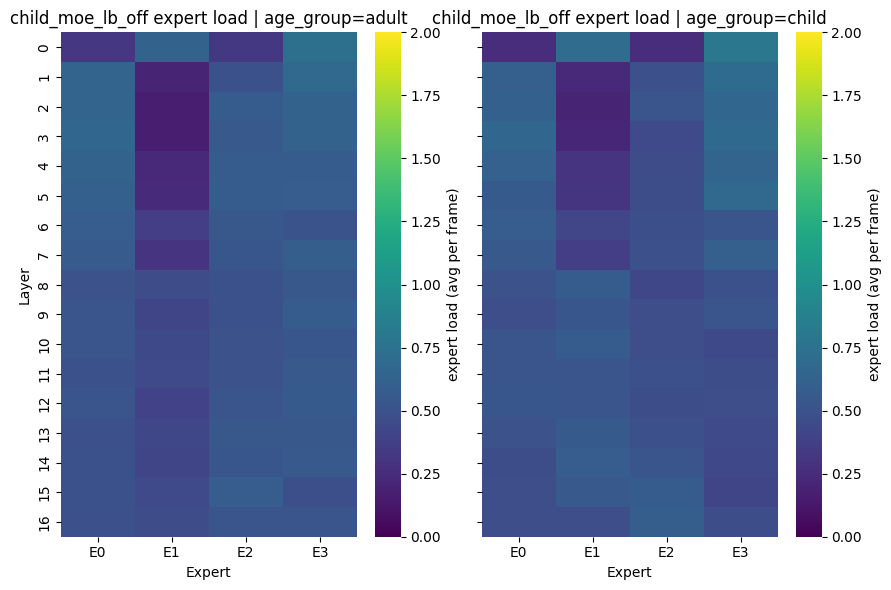

In [58]:
# Expert load profiles (adult vs child) per model
for model_name, df in all_routing.items():
    save_path = f"{ROUTING_CACHE_DIR}/{model_name}_expert_load_age.png"
    plot_expert_load_heatmaps(
        df, group_col="age_group",
        title_prefix=f"{model_name} expert load",
        save_path=save_path,
        n_layers=17,
    )

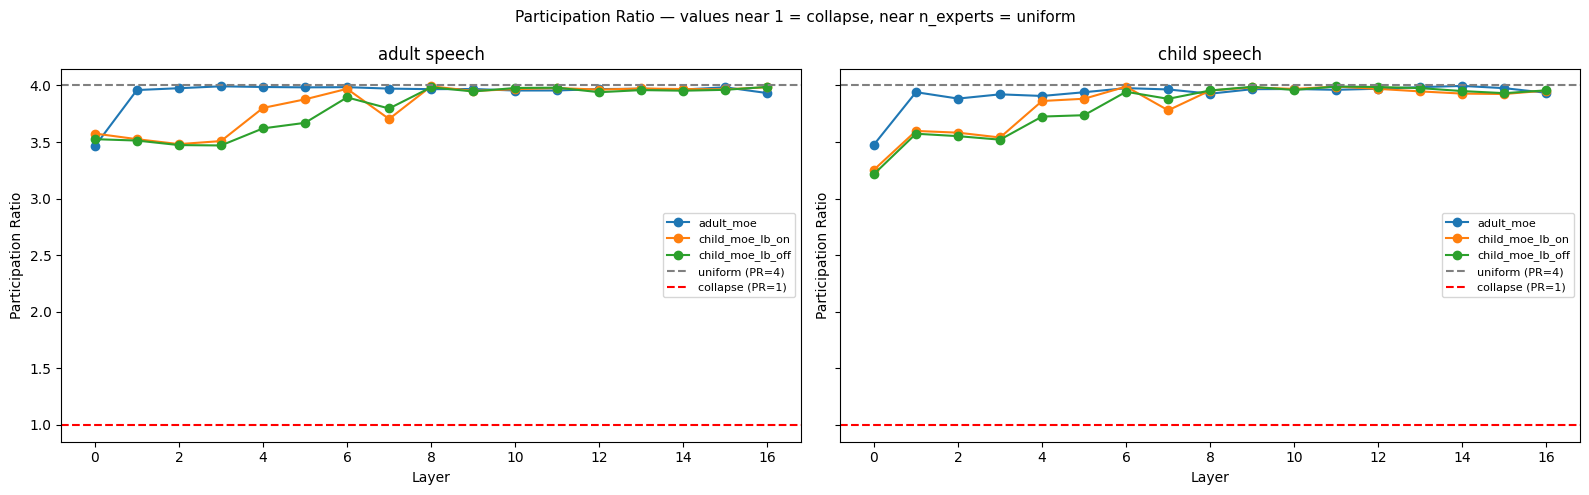

In [59]:
def plot_participation_ratio(all_routing):
    expert_cols = _expert_cols(next(iter(all_routing.values())))
    n_experts = len(expert_cols)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, age_group in zip(axes, ["adult", "child"]):
        for model_name, df in all_routing.items():
            df_age = df[df["age_group"] == age_group]
            prs = []
            for layer_idx in range(17):
                df_l = df_age[df_age["layer_idx"] == layer_idx]
                probs = _mean_probs(df_l, expert_cols)
                if probs is None:
                    prs.append(np.nan)
                    continue
                # PR is invariant to scaling; normalize for interpretability
                pr = 1.0 / np.sum(probs ** 2)
                prs.append(pr)
            ax.plot(range(17), prs, marker="o", label=model_name)

        ax.axhline(n_experts, color="gray", linestyle="--",
                   label=f"uniform (PR={n_experts})")
        ax.axhline(1, color="red", linestyle="--",
                   label="collapse (PR=1)")
        ax.set_title(f"{age_group} speech")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Participation Ratio")
        ax.legend(fontsize=8)

    plt.suptitle("Participation Ratio — values near 1 = collapse, "
                 "near n_experts = uniform", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{ROUTING_CACHE_DIR}/participation_ratio.png",
                dpi=150, bbox_inches="tight")
    plt.show()

plot_participation_ratio(all_routing)

In [60]:
def compute_and_plot_jsd(all_routing, n_layers=17):
    results = []

    for model_name, df in all_routing.items():
        df_adult_all = df[df["age_group"] == "adult"]
        df_child_all = df[df["age_group"] == "child"]

        if df_adult_all.empty or df_child_all.empty:
            continue

        mean_vals, ci_low, ci_high = bootstrap_jsd_per_layer(
            df_adult_all, df_child_all, n_layers=n_layers
        )

        for layer_idx in range(n_layers):
            if np.isnan(mean_vals[layer_idx]):
                continue

            df_l = df[df["layer_idx"] == layer_idx]
            df_adult = df_l[df_l["age_group"] == "adult"]
            df_child = df_l[df_l["age_group"] == "child"]

            chi2_stat, p_val, dof, sig = chi2_significance_duration_matched(
                df_adult, df_child, n_experts=len(_expert_cols(df)), seed=42
            )

            results.append({
                "model": model_name,
                "layer_idx": layer_idx,
                "jsd_mean": mean_vals[layer_idx],
                "jsd_ci_low": ci_low[layer_idx],
                "jsd_ci_high": ci_high[layer_idx],
                "chi2": chi2_stat,
                "chi2_dof": dof,
                "p_value": p_val,
                "significant": sig,
            })

    results_df = pd.DataFrame(results)

    # Benjamini-Hochberg FDR correction for chi2 tests (ignore NaNs)
    valid_mask = results_df["p_value"].notna()
    p_adj_full = np.full(len(results_df), np.nan)
    sig_full = np.zeros(len(results_df), dtype=bool)

    if valid_mask.any():
        _, p_adj_valid, _, _ = multipletests(
            results_df.loc[valid_mask, "p_value"].values,
            alpha=0.05,
            method="fdr_bh",
        )
        p_adj_full[valid_mask.values] = p_adj_valid
        sig_full[valid_mask.values] = p_adj_valid < 0.05

    results_df["p_adj"] = p_adj_full
    results_df["significant_bh"] = sig_full

    out_csv = f"{ROUTING_CACHE_DIR}/divergence_results.csv"
    results_df.to_csv(out_csv, index=False)
    return results_df

results_df = compute_and_plot_jsd(all_routing)
print(results_df[["model", "layer_idx", "jsd_mean", "p_value", "p_adj", "significant_bh"]])

               model  layer_idx  jsd_mean        p_value          p_adj  \
0          adult_moe          0  0.001497   1.775511e-29   2.159405e-29   
1          adult_moe          1  0.000120   3.215621e-04   3.365185e-04   
2          adult_moe          2  0.001655   2.560971e-62   3.841456e-62   
3          adult_moe          3  0.002492  3.062169e-167  7.655421e-167   
4          adult_moe          4  0.002511   5.774305e-51   7.874053e-51   
5          adult_moe          5  0.001993   1.212633e-96   2.372544e-96   
6          adult_moe          6  0.001072  5.695833e-106  1.220536e-105   
7          adult_moe          7  0.000806   7.835850e-67   1.259333e-66   
8          adult_moe          8  0.001646   1.841751e-63   2.857889e-63   
9          adult_moe          9  0.000566   1.212323e-36   1.515404e-36   
10         adult_moe         10  0.000135   4.152572e-19   4.671643e-19   
11         adult_moe         11  0.000041   7.544858e-05   8.083776e-05   
12         adult_moe     

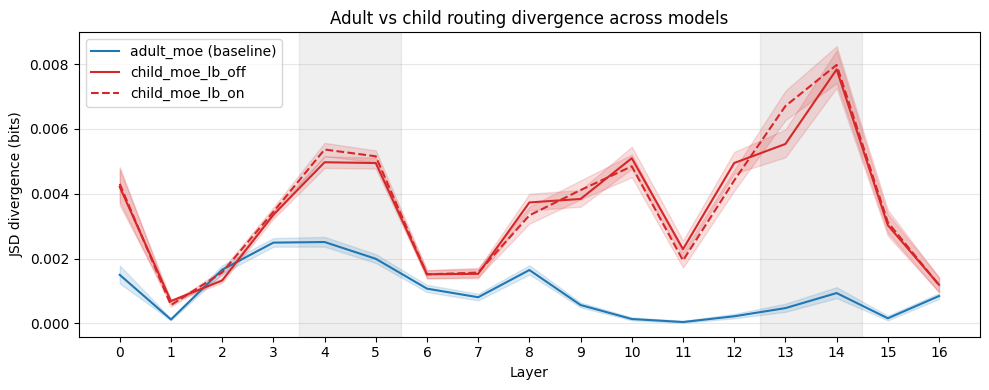

<Figure size 640x480 with 0 Axes>

In [66]:
# Plot 1 — Adult vs child routing divergence across models
PEAK_BANDS = [(4, 5), (13, 14)]
MODEL_ORDER = ["adult_moe", "child_moe_lb_off", "child_moe_lb_on"]
MODEL_LABELS = {
    "adult_moe": "adult_moe (baseline)",
    "child_moe_lb_off": "child_moe_lb_off",
    "child_moe_lb_on": "child_moe_lb_on",
}
MODEL_STYLES = {
    "adult_moe": {"color": "#1f77b4", "linestyle": "-"},
    "child_moe_lb_off": {"color": "#d62728", "linestyle": "-"},
    "child_moe_lb_on": {"color": "#d62728", "linestyle": "--"},
}

fig, ax = plt.subplots(figsize=(10, 4))
for start, end in PEAK_BANDS:
    ax.axvspan(start - 0.5, end + 0.5, color="gray", alpha=0.12, zorder=0)

x = np.arange(17)
for model_name in MODEL_ORDER:
    if model_name not in all_routing:
        continue
    df = all_routing[model_name]
    df_adult = df[df["age_group"] == "adult"]
    df_child = df[df["age_group"] == "child"]
    mean_vals, ci_low, ci_high = bootstrap_jsd_per_layer(df_adult, df_child, n_layers=17)
    style = MODEL_STYLES.get(model_name, {})
    ax.plot(x, mean_vals, label=MODEL_LABELS.get(model_name, model_name), **style)
    ax.fill_between(x, ci_low, ci_high, color=style.get("color", "#444444"), alpha=0.15)

ax.set_xticks(range(17))
ax.set_xlabel("Layer")
ax.set_ylabel("JSD divergence (bits)")
ax.set_title("Adult vs child routing divergence across models")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f"{ROUTING_CACHE_DIR}/jsd_by_model_lines.png", dpi=150, bbox_inches="tight")
plt.show()

# # Plot 2 — Expert load differences at peak layers (child minus adult)
# PLOT2_MODELS = ["adult_moe", "child_moe_lb_off"]
# PLOT2_LAYERS = [5, 14]

# fig, axes = plt.subplots(
#     len(PLOT2_LAYERS), len(PLOT2_MODELS),
#     figsize=(4.2 * len(PLOT2_MODELS), 3.2 * len(PLOT2_LAYERS)),
#     sharex=True, sharey=True,
# )
# if len(PLOT2_LAYERS) == 1:
#     axes = np.array([axes])
# if len(PLOT2_MODELS) == 1:
#     axes = axes.reshape(len(PLOT2_LAYERS), 1)

# for r, layer_idx in enumerate(PLOT2_LAYERS):
#     for c, model_name in enumerate(PLOT2_MODELS):
#         ax = axes[r, c]
#         if model_name not in all_routing:
#             ax.axis("off")
#             continue
#         df = all_routing[model_name]
#         expert_cols = _expert_cols(df)
#         n_experts = len(expert_cols)
#         df_l = df[df["layer_idx"] == layer_idx]
#         adult = _mean_probs(df_l[df_l["age_group"] == "adult"], expert_cols)
#         child = _mean_probs(df_l[df_l["age_group"] == "child"], expert_cols)
#         if adult is None or child is None:
#             ax.axis("off")
#             continue
#         diff = K_TOP * (child - adult)

#         y = np.arange(n_experts)
#         colors = ["#ff7f0e" if v > 0 else "#1f77b4" for v in diff]
#         ax.barh(y, diff, color=colors)
#         ax.axvline(0, color="gray", linewidth=1)
#         ax.set_yticks(y)
#         ax.set_yticklabels([f"E{i}" for i in range(n_experts)])
#         ax.set_title(f"{model_name} — L{layer_idx}")
#         if r == len(PLOT2_LAYERS) - 1:
#             ax.set_xlabel("child − adult load")

plt.tight_layout()
plt.savefig(f"{ROUTING_CACHE_DIR}/expert_load_peak_layers_diff.png", dpi=150, bbox_inches="tight")
plt.show()

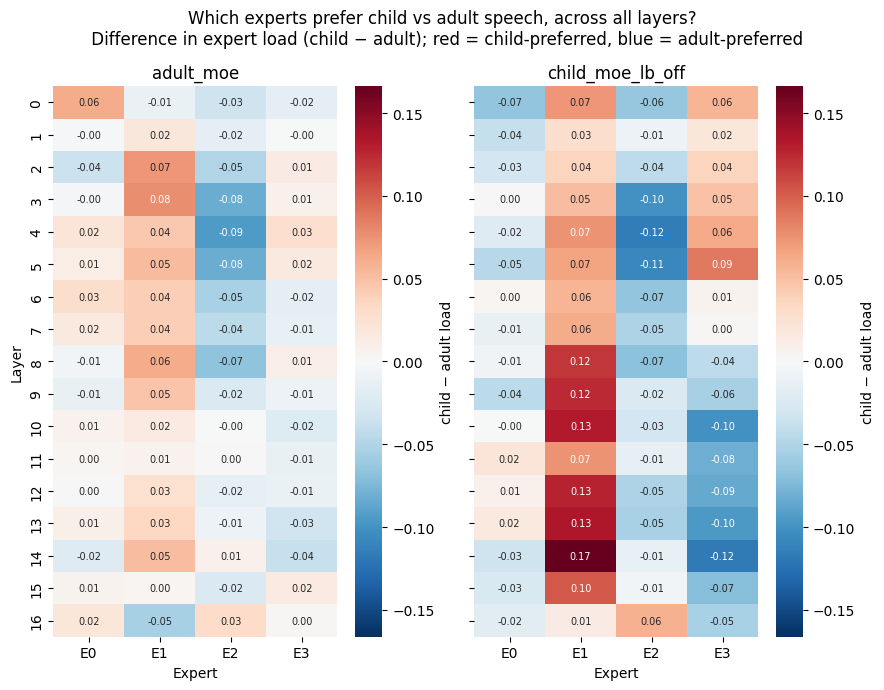

In [65]:
PLOT2_MODELS = ["adult_moe", "child_moe_lb_off"]
N_LAYERS = 17

fig, axes = plt.subplots(1, len(PLOT2_MODELS), figsize=(4.5 * len(PLOT2_MODELS), 7), sharey=True)
if len(PLOT2_MODELS) == 1:
    axes = [axes]

# Find global vmax for shared colour scale across both panels
global_max = 0
diff_matrices = {}
for model_name in PLOT2_MODELS:
    if model_name not in all_routing:
        continue
    df = all_routing[model_name]
    expert_cols = _expert_cols(df)
    n_experts = len(expert_cols)
    mat = np.full((N_LAYERS, n_experts), np.nan)
    for layer_idx in range(N_LAYERS):
        df_l = df[df["layer_idx"] == layer_idx]
        adult = _mean_probs(df_l[df_l["age_group"] == "adult"], expert_cols)
        child = _mean_probs(df_l[df_l["age_group"] == "child"], expert_cols)
        if adult is None or child is None:
            continue
        mat[layer_idx] = K_TOP * (child - adult)
    diff_matrices[model_name] = mat
    if np.any(~np.isnan(mat)):
        global_max = max(global_max, np.nanmax(np.abs(mat)))

# Use a symmetric scale; cap small to keep colour resolution
vmax = max(global_max, 0.05)

for ax, model_name in zip(axes, PLOT2_MODELS):
    if model_name not in diff_matrices:
        ax.axis("off")
        continue
    mat = diff_matrices[model_name]
    n_experts = mat.shape[1]
    sns.heatmap(
        mat, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
        xticklabels=[f"E{i}" for i in range(n_experts)],
        yticklabels=range(N_LAYERS),
        cbar_kws={"label": "child − adult load"},
        annot=True, fmt=".2f", annot_kws={"size": 7},
    )
    ax.set_title(model_name)
    ax.set_xlabel("Expert")

axes[0].set_ylabel("Layer")
# plt.title("")
plt.suptitle("Which experts prefer child vs adult speech, across all layers? \n Difference in expert load (child − adult); red = child-preferred, blue = adult-preferred")
plt.tight_layout()
plt.savefig(f"{ROUTING_CACHE_DIR}/expert_load_diff_all_layers.png", dpi=150, bbox_inches="tight")
plt.show()

## Domain Control: LibriSpeech vs MyST vs YODAS (English)
We compare two adult domains (LibriSpeech, YODAS) and one child domain (MyST).
If routing reflects age rather than recording conditions, LibriSpeech and YODAS should be more similar to each other than to MyST.

In [62]:
# Domain control uses the model configured during extraction (typically child_moe_lb_off)
DOMAIN_CACHE = f"{ROUTING_CACHE_DIR}/domain_control_routing.csv"

if not os.path.exists(DOMAIN_CACHE):
    raise FileNotFoundError(
        f"Missing domain control cache: {DOMAIN_CACHE}\n"
        "Run scripts/experiments/routing_analysis/extract_routing.py --domain-control to generate it."
    )

df_domain = pd.read_csv(DOMAIN_CACHE)

if not any(c.startswith("expert_") and c.endswith("_prob") for c in df_domain.columns):
    raise ValueError(
        "Expected columns like expert_0_prob in domain control cache."
    )

# Plot 4 — Domain control
pairs = [("librispeech", "myst"), ("librispeech", "yodas"), ("myst", "yodas")]
fig, ax = plt.subplots(figsize=(12, 4))
for start, end in PEAK_BANDS:
    ax.axvspan(start - 0.5, end + 0.5, color="gray", alpha=0.12, zorder=0)

for a, b in pairs:
    if a not in df_domain["dataset_source"].unique() or b not in df_domain["dataset_source"].unique():
        continue
    mean_vals, ci_low, ci_high = bootstrap_jsd_per_layer(
        df_domain[df_domain["dataset_source"] == a],
        df_domain[df_domain["dataset_source"] == b],
        n_layers=17,
    )
    x = np.arange(17)
    ax.plot(x, mean_vals, marker="o", label=f"{a} vs {b}")
    ax.fill_between(x, ci_low, ci_high, alpha=0.15)

ax.set_xticks(range(17))
ax.set_xticklabels([f"L{i}" for i in range(17)])
ax.set_xlabel("Layer")
ax.set_ylabel("JSD divergence (bits)")
ax.set_title("Domain Control: Routing divergence across English domains")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f"{ROUTING_CACHE_DIR}/jsd_domain_control.png", dpi=150, bbox_inches="tight")
plt.show()

# Expert load heatmaps for the three domains
plot_expert_load_heatmaps(
    df_domain, group_col="dataset_source",
    title_prefix="Domain control expert load",
    save_path=f"{ROUTING_CACHE_DIR}/expert_load_domain_control.png",
    n_layers=17,
)

FileNotFoundError: Missing domain control cache: /lp-dev/amelia/inclusive-asr-moe/routing_outputs_en/domain_control_routing.csv
Run scripts/experiments/routing_analysis/extract_routing.py --domain-control to generate it.

## Age-Group Routing Divergence & Correlation
Calculate JSD, Chi-Square, and Spearman correlation with acoustic properties.


In [69]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

def per_expert_significance(all_routing, n_layers=17, seed=42):
    """
    For each (model, layer, expert), test whether the rate at which adults
    vs children are routed to that expert (as top-1) differs significantly.

    Uses a 2x2 contingency table per expert:
        rows = age group (adult, child)
        cols = (this expert chosen, any other expert chosen)

    Duration-matches adult vs child samples per layer before testing.
    Applies Benjamini-Hochberg FDR correction across all (model, layer, expert)
    tests for each model independently.

    Returns a DataFrame with one row per (model, layer, expert).
    """
    results = []

    for model_name, df in all_routing.items():
        if "top1_expert" not in df.columns:
            print(f"Skipping {model_name}: no 'top1_expert' column")
            continue

        expert_cols = _expert_cols(df)
        n_experts = len(expert_cols)

        for layer in range(n_layers):
            df_l = df[df["layer_idx"] == layer]
            df_adult = df_l[df_l["age_group"] == "adult"]
            df_child = df_l[df_l["age_group"] == "child"]

            if df_adult.empty or df_child.empty:
                continue

            # Duration-match so test isn't dominated by the larger group
            dur_a = _duration_col(df_adult).sum()
            dur_c = _duration_col(df_child).sum()
            if not (np.isfinite(dur_a) and np.isfinite(dur_c)):
                continue
            target = min(float(dur_a), float(dur_c))

            sub_a = subsample_by_duration(df_adult, target, seed=seed)
            sub_c = subsample_by_duration(df_child, target, seed=seed + 1)

            if sub_a.empty or sub_c.empty:
                continue

            for e in range(n_experts):
                a_this = int((sub_a["top1_expert"] == e).sum())
                a_other = len(sub_a) - a_this
                c_this = int((sub_c["top1_expert"] == e).sum())
                c_other = len(sub_c) - c_this

                table = np.array([[a_this, a_other], [c_this, c_other]])
                if table.sum(axis=1).min() == 0 or table.sum(axis=0).min() == 0:
                    p_val = np.nan
                    chi2_stat = np.nan
                else:
                    try:
                        chi2_stat, p_val, _, _ = chi2_contingency(table)
                    except ValueError:
                        chi2_stat, p_val = np.nan, np.nan

                # Direction: positive = child-preferred, negative = adult-preferred
                rate_adult = a_this / max(len(sub_a), 1)
                rate_child = c_this / max(len(sub_c), 1)
                diff = rate_child - rate_adult

                results.append({
                    "model": model_name,
                    "layer_idx": layer,
                    "expert": e,
                    "rate_adult": rate_adult,
                    "rate_child": rate_child,
                    "diff_child_minus_adult": diff,
                    "chi2": chi2_stat,
                    "p_value": p_val,
                })

    df_sig = pd.DataFrame(results)

    # BH-FDR correction *per model* (each model is its own multiple-comparison family)
    df_sig["p_adj"] = np.nan
    df_sig["significant_bh"] = False
    for model_name in df_sig["model"].unique():
        mask = (df_sig["model"] == model_name) & df_sig["p_value"].notna()
        if mask.sum() == 0:
            continue
        _, p_adj, _, _ = multipletests(
            df_sig.loc[mask, "p_value"].values,
            alpha=0.05, method="fdr_bh"
        )
        df_sig.loc[mask, "p_adj"] = p_adj
        df_sig.loc[mask, "significant_bh"] = p_adj < 0.05

    out_csv = f"{ROUTING_CACHE_DIR}/per_expert_significance.csv"
    df_sig.to_csv(out_csv, index=False)
    print(f"Saved {out_csv}")
    return df_sig

# Run per-expert significance tests
df_sig = per_expert_significance(all_routing, n_layers=17)

# Summary: how many (layer, expert) cells are significant per model?
print("\nSignificant (layer, expert) cells per model (BH-corrected, alpha=0.05):")
summary = df_sig.groupby("model")["significant_bh"].agg(["sum", "count"])
summary.columns = ["n_significant", "n_tests"]
print(summary)

# Top 10 strongest specialisations (largest |child − adult| rate difference, BH-significant)
print("\nTop 10 strongest expert specialisations (BH-significant only):")
sig_rows = df_sig[df_sig["significant_bh"]].copy()
sig_rows["abs_diff"] = sig_rows["diff_child_minus_adult"].abs()
print(
    sig_rows
    .sort_values("abs_diff", ascending=False)
    .head(10)[["model", "layer_idx", "expert", "rate_adult", "rate_child",
               "diff_child_minus_adult", "p_adj"]]
    .to_string(index=False)
)

# After sns.heatmap(...) for each panel:
df_sig_model = df_sig[df_sig["model"] == model_name]
for _, row in df_sig_model.iterrows():
    if row["significant_bh"]:
        ax.text(
            row["expert"] + 0.85, row["layer_idx"] + 0.85, "*",
            ha="center", va="center", fontsize=11,
            fontweight="bold", color="black",
        )

Saved /lp-dev/amelia/inclusive-asr-moe/routing_outputs_en/per_expert_significance.csv

Significant (layer, expert) cells per model (BH-corrected, alpha=0.05):
                  n_significant  n_tests
model                                   
adult_moe                    55       68
child_moe_lb_off             59       68
child_moe_lb_on              56       68

Top 10 strongest expert specialisations (BH-significant only):
           model  layer_idx  expert  rate_adult  rate_child  diff_child_minus_adult         p_adj
child_moe_lb_off          5       3    0.260305    0.831070                0.570765  0.000000e+00
child_moe_lb_off          4       3    0.167557    0.591054                0.423497 1.406388e-213
child_moe_lb_off          8       1    0.071756    0.486022                0.414267 3.938414e-240
 child_moe_lb_on         13       1    0.064122    0.457268                0.393146 1.502114e-225
 child_moe_lb_on          8       1    0.109160    0.496006                0.38684

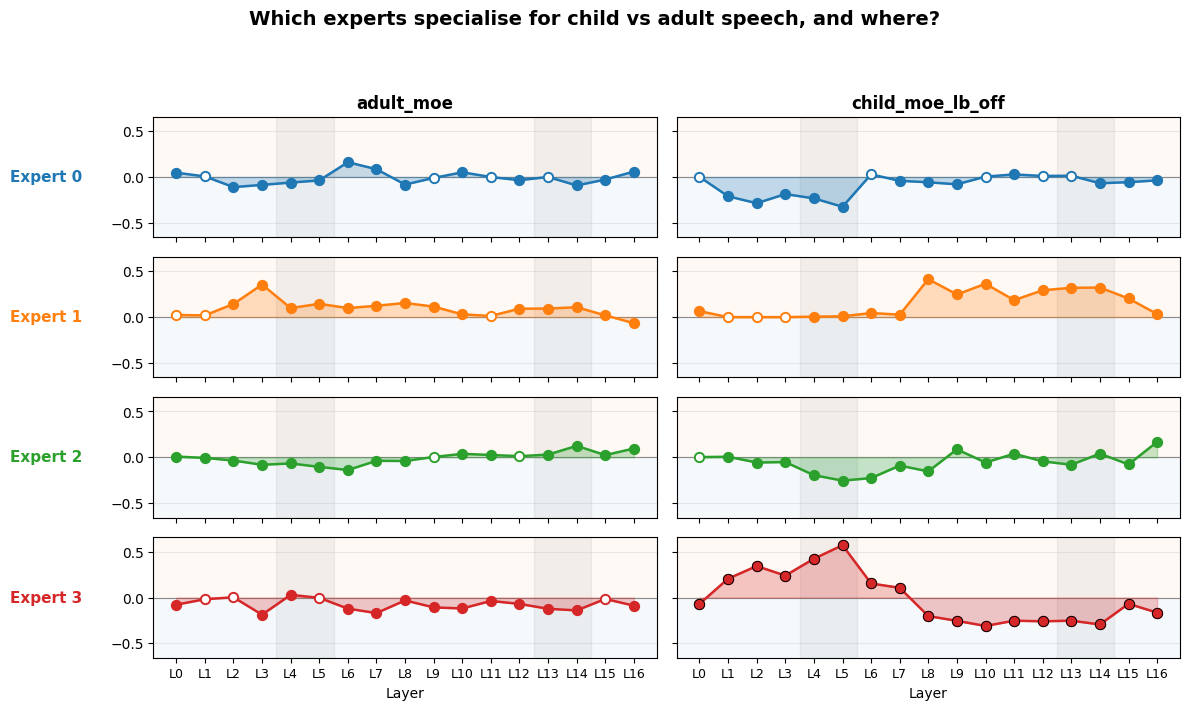

In [109]:
# Plot 3 — Per-expert specialisation across layers
# Uses df_sig from per_expert_significance.
# Shows each expert as its own row so the lines never overlap.

if "df_sig" not in globals() or df_sig is None or df_sig.empty:
    print("df_sig is empty; run the per_expert_significance cell first.")
else:
    PLOT3_MODELS = ["adult_moe", "child_moe_lb_off"]
    PEAK_BANDS = [(4, 5), (13, 14)]
    N_LAYERS = 17
    EXPERT_COLORS = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c", 3: "#d62728"}

    n_experts = df_sig["expert"].max() + 1
    global_max = df_sig["diff_child_minus_adult"].abs().max()
    ylim = (-global_max * 1.15, global_max * 1.15)

    fig, axes = plt.subplots(
        n_experts, len(PLOT3_MODELS),
        figsize=(6 * len(PLOT3_MODELS), 1.8 * n_experts),
        sharex=True, sharey=True,
    )
    if n_experts == 1:
        axes = axes.reshape(1, -1)
    if len(PLOT3_MODELS) == 1:
        axes = axes.reshape(-1, 1)

    for col_idx, model_name in enumerate(PLOT3_MODELS):
        df_m = df_sig[df_sig["model"] == model_name]

        for e in range(n_experts):
            ax = axes[e, col_idx]
            color = EXPERT_COLORS.get(e, "#444444")

            # Shade peak bands
            for start, end in PEAK_BANDS:
                ax.axvspan(start - 0.5, end + 0.5, color="gray", alpha=0.10, zorder=0)

            # Light shading for child/adult regions
            ax.axhspan(0, ylim[1], color="#ff7f0e", alpha=0.04, zorder=0)
            ax.axhspan(ylim[0], 0, color="#1f77b4", alpha=0.04, zorder=0)

            ax.axhline(0, color="gray", linewidth=0.8, zorder=1)

            df_e = df_m[df_m["expert"] == e].sort_values("layer_idx")
            if df_e.empty:
                ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center")
                continue

            vals = df_e.set_index("layer_idx")["diff_child_minus_adult"].reindex(range(N_LAYERS)).values
            sig = df_e.set_index("layer_idx")["significant_bh"].reindex(range(N_LAYERS)).fillna(False).values

            x = np.arange(N_LAYERS)
            # Fill area under line for visual clarity
            ax.fill_between(x, vals, 0, alpha=0.25, color=color, zorder=2)
            ax.plot(x, vals, color=color, linewidth=1.8, zorder=3)

            # Markers: filled if significant, hollow if not
            for xi, yi, s in zip(x, vals, sig):
                if np.isnan(yi):
                    continue
                ax.scatter(
                    [xi], [yi], s=45,
                    facecolors=color if s else "white",
                    edgecolors=color, linewidths=1.4, zorder=4,
                )

            ax.set_ylim(ylim)
            ax.grid(axis="y", alpha=0.25)

            # Row labels (expert) on leftmost column
            if col_idx == 0:
                ax.set_ylabel(f"Expert {e}", fontsize=11, fontweight="bold",
                              color=color, rotation=0, ha="right", va="center", labelpad=20)

            # Column titles (model) on top row only
            if e == 0:
                ax.set_title(model_name, fontsize=12, fontweight="bold")

            # X-axis labels on bottom row only
            if e == n_experts - 1:
                ax.set_xticks(range(N_LAYERS))
                ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)], fontsize=9)
                ax.set_xlabel("Layer")
            else:
                ax.set_xticks(range(N_LAYERS))
                ax.set_xticklabels([])

    fig.suptitle(
        "Which experts specialise for child vs adult speech, and where?",
        fontsize=14, fontweight="bold",
    )
    

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f"{ROUTING_CACHE_DIR}/per_expert_specialisation.png",
                dpi=150, bbox_inches="tight")

    # Plot line lightly for trend
    ax.plot(x, vals, color=color, linewidth=1.2, alpha=0.35, zorder=2)

    # Plot non-significant points faintly
    nonsig_mask = ~sig
    ax.scatter(
        x[nonsig_mask], vals[nonsig_mask],
        s=35,
        facecolors="white",
        edgecolors=color,
        linewidths=1.0,
        alpha=0.35,
        zorder=3,
    )

    # Plot significant points strongly
    sig_mask = sig
    ax.scatter(
        x[sig_mask], vals[sig_mask],
        s=55,
        facecolors=color,
        edgecolors="black",
        linewidths=0.7,
        alpha=1.0,
        zorder=4,
    )
    plt.show()

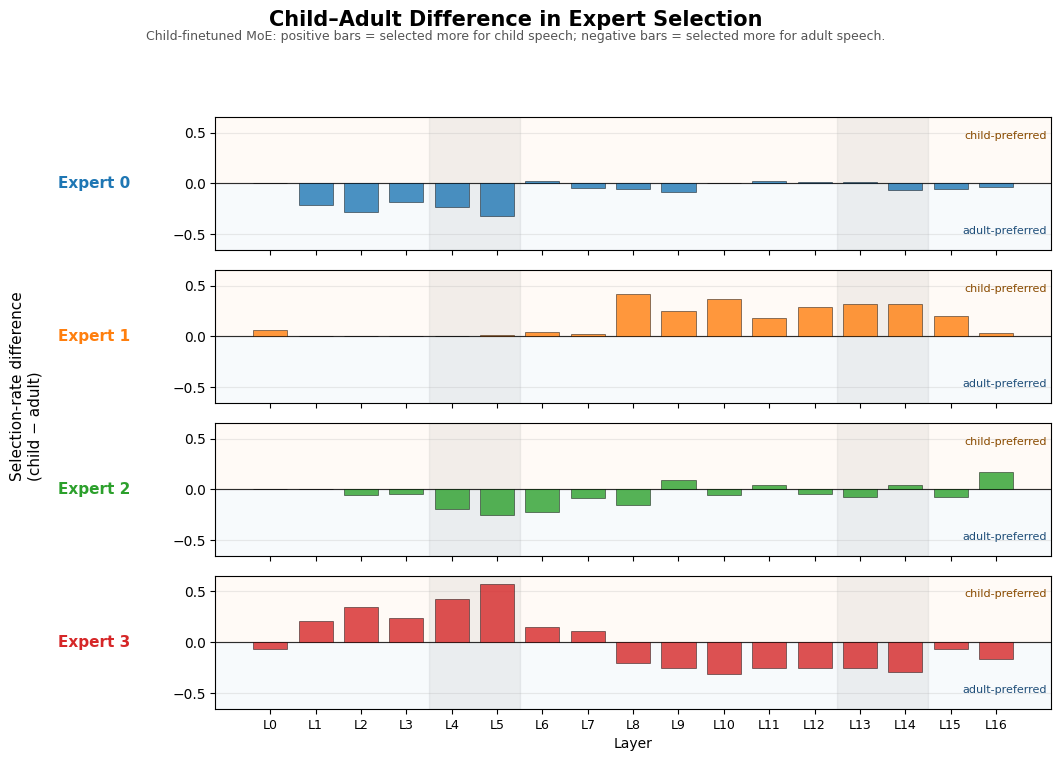

Saved /lp-dev/amelia/inclusive-asr-moe/routing_outputs_en/child_moe_lb_off_per_expert_bars.png


In [110]:
# Plot — Per-expert child/adult preference as bars
# Model: child_moe_lb_off only
# Metric: diff_child_minus_adult = child top-1 selection rate − adult top-1 selection rate
# Positive bars = child-preferred expert
# Negative bars = adult-preferred expert

import numpy as np
import matplotlib.pyplot as plt

if "df_sig" not in globals() or df_sig is None or df_sig.empty:
    print("df_sig is empty; run the per_expert_significance cell first.")
else:
    MODEL_NAME = "child_moe_lb_off"
    MODEL_LABEL = "Child-finetuned MoE"
    N_LAYERS = 17
    PEAK_BANDS = [(4, 5), (13, 14)]

    EXPERT_COLORS = {
        0: "#1f77b4",
        1: "#ff7f0e",
        2: "#2ca02c",
        3: "#d62728",
    }

    df_m = df_sig[df_sig["model"] == MODEL_NAME].copy()

    if df_m.empty:
        print(f"No rows found for model: {MODEL_NAME}")
    else:
        n_experts = int(df_m["expert"].max()) + 1

        global_max = df_m["diff_child_minus_adult"].abs().max()
        ylim = (-global_max * 1.15, global_max * 1.15)

        fig, axes = plt.subplots(
            n_experts,
            1,
            figsize=(11, 1.9 * n_experts),
            sharex=True,
            sharey=True,
        )

        if n_experts == 1:
            axes = [axes]

        x = np.arange(N_LAYERS)

        for e, ax in enumerate(axes):
            color = EXPERT_COLORS.get(e, "#444444")

            # Shade previously identified peak bands
            for start, end in PEAK_BANDS:
                ax.axvspan(
                    start - 0.5,
                    end + 0.5,
                    color="gray",
                    alpha=0.10,
                    zorder=0,
                )

            # Background: child-preferred vs adult-preferred region
            ax.axhspan(0, ylim[1], color="#ff7f0e", alpha=0.035, zorder=0)
            ax.axhspan(ylim[0], 0, color="#1f77b4", alpha=0.035, zorder=0)

            ax.axhline(0, color="black", linewidth=0.8, zorder=1)

            df_e = df_m[df_m["expert"] == e].sort_values("layer_idx")
            vals = (
                df_e
                .set_index("layer_idx")["diff_child_minus_adult"]
                .reindex(range(N_LAYERS))
                .values
            )

            # Bars only
            ax.bar(
                x,
                vals,
                color=color,
                alpha=0.80,
                width=0.75,
                edgecolor="black",
                linewidth=0.4,
                zorder=2,
            )

            ax.set_ylim(ylim)
            ax.grid(axis="y", alpha=0.25, zorder=0)

            ax.set_ylabel(
                f"Expert {e}",
                fontsize=11,
                fontweight="bold",
                color=color,
                rotation=0,
                ha="right",
                va="center",
                labelpad=30,
            )

            # Optional small labels inside each row
            ax.text(
                0.995,
                0.86,
                "child-preferred",
                transform=ax.transAxes,
                ha="right",
                va="center",
                fontsize=8,
                color="#8a4b00",
            )
            ax.text(
                0.995,
                0.14,
                "adult-preferred",
                transform=ax.transAxes,
                ha="right",
                va="center",
                fontsize=8,
                color="#1f4e79",
            )

        axes[-1].set_xticks(range(N_LAYERS))
        axes[-1].set_xticklabels([f"L{i}" for i in range(N_LAYERS)], fontsize=9)
        axes[-1].set_xlabel("Layer")

        fig.suptitle(
            "Child–Adult Difference in Expert Selection",
            fontsize=15,
            fontweight="bold",
            y=0.995,
        )

        fig.text(
            0.5,
            0.955,
            f"{MODEL_LABEL}: positive bars = selected more for child speech; "
            "negative bars = selected more for adult speech.",
            ha="center",
            fontsize=9,
            color="#555555",
        )

        fig.text(
            0.04,
            0.5,
            "Selection-rate difference\n(child − adult)",
            va="center",
            rotation="vertical",
            fontsize=11,
        )

        plt.tight_layout(rect=[0.07, 0, 1, 0.92])

        save_path = f"{ROUTING_CACHE_DIR}/child_moe_lb_off_per_expert_bars.png"
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.show()

        print(f"Saved {save_path}")

## Phase 2: Functional Analysis
(Only activated if significant signal is found in Phase 1)
- Method 1: Cosine similarity on top candidate experts
- Method 2: Probing classifiers
- Method 3: CKA


In [77]:
import nemo.collections.asr as nemo_asr

m = nemo_asr.models.EncDecCTCModelBPE.restore_from(
    MODELS["child_moe_lb_off"], map_location="cpu"
)
m.eval()

print("=== ENCODER CHILDREN ===")
for name, child in m.encoder.named_children():
    print(f"  encoder.{name}: {type(child).__name__}")

print("\n=== ALL ENCODER MODULES CONTAINING 'expert' OR 'moe' ===")
for name, mod in m.encoder.named_modules():
    if "expert" in name.lower() or "moe" in name.lower():
        print(f"  {name}: {type(mod).__name__}")

print("\n=== LAYER 5 FEED_FORWARD STRUCTURE (full) ===")
ff = m.encoder.layers[5].feed_forward
print(f"  type: {type(ff).__name__}")
for name, mod in ff.named_modules():
    if name:
        print(f"  ff.{name}: {type(mod).__name__}")

print("\n=== LAYER 5 FEED_FORWARD PARAMETERS ===")
for name, p in ff.named_parameters():
    print(f"  {name}: shape={tuple(p.shape)}")

print("\n=== ENCODER-LEVEL PARAMETERS WITH 'expert' IN NAME ===")
for name, p in m.encoder.named_parameters():
    if "expert" in name.lower():
        print(f"  {name}: shape={tuple(p.shape)}")

[NeMo I 2026-05-27 10:46:35 mixins:184] Tokenizer SentencePieceTokenizer initialized with 4096 tokens


[NeMo W 2026-05-27 10:46:35 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    input_cfg: /lp-dev/amelia/inclusive-asr-moe/data/english/finetune_myst_train.yaml
    skip_missing_manifest_entries: true
    num_workers: 4
    shuffle: true
    normalize_text: true
    use_lhotse: true
    force_iterable_dataset: true
    min_duration: 1.0
    max_duration: 30.0
    num_buckets: 10
    use_distributed_sampler: false
    bucket_duration_bins:
    - 1.0
    - 3.0
    - 5.0
    - 7.0
    - 9.0
    - 11.0
    - 13.0
    - 15.0
    - 20.0
    - 25.0
    bucket_batch_size:
    - 576
    - 432
    - 288
    - 216
    - 180
    - 144
    - 126
    - 108
    - 72
    - 54
    use_bucketing: true
    
[NeMo W 2026-05-27 10:46:35 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_

[NeMo I 2026-05-27 10:46:37 conformer_moe_encoder:467] Created ConformerMoEEncoder with 17 layers, 4 experts per layer, top-2 routing [global shared router]
[NeMo I 2026-05-27 10:46:48 save_restore_connector:286] Model EncDecCTCModelBPE was successfully restored from /lp-dev/amelia/inclusive-asr-moe/final_weights/en_child_moe_lb_off.nemo.
=== ENCODER CHILDREN ===
  encoder.pre_encode: ConvSubsampling
  encoder.pos_enc: RelPositionalEncoding
  encoder.global_router: OmniRouter
  encoder.layers: ModuleList

=== ALL ENCODER MODULES CONTAINING 'expert' OR 'moe' ===

=== LAYER 5 FEED_FORWARD STRUCTURE (full) ===
  type: ConformerMoEFeedForward
  ff.activation: Swish
  ff.dropout: Dropout

=== LAYER 5 FEED_FORWARD PARAMETERS ===
  w1: shape=(4, 2048, 512)
  w2: shape=(4, 512, 2048)
  b1: shape=(4, 2048)
  b2: shape=(4, 512)

=== ENCODER-LEVEL PARAMETERS WITH 'expert' IN NAME ===


In [78]:
import nemo.collections.asr as nemo_asr

m = nemo_asr.models.EncDecCTCModelBPE.restore_from(
    MODELS["child_moe_lb_off"], map_location="cpu"
)
m.eval()

print("=== ENCODER CHILDREN ===")
for name, child in m.encoder.named_children():
    print(f"  encoder.{name}: {type(child).__name__}")

print("\n=== ALL ENCODER MODULES CONTAINING 'expert' OR 'moe' ===")
for name, mod in m.encoder.named_modules():
    if "expert" in name.lower() or "moe" in name.lower():
        print(f"  {name}: {type(mod).__name__}")

print("\n=== LAYER 5 FEED_FORWARD STRUCTURE (full) ===")
ff = m.encoder.layers[5].feed_forward
print(f"  type: {type(ff).__name__}")
for name, mod in ff.named_modules():
    if name:
        print(f"  ff.{name}: {type(mod).__name__}")

print("\n=== LAYER 5 FEED_FORWARD PARAMETERS ===")
for name, p in ff.named_parameters():
    print(f"  {name}: shape={tuple(p.shape)}")

print("\n=== ENCODER-LEVEL PARAMETERS WITH 'expert' IN NAME ===")
for name, p in m.encoder.named_parameters():
    if "expert" in name.lower():
        print(f"  {name}: shape={tuple(p.shape)}")

[NeMo I 2026-05-27 10:49:55 mixins:184] Tokenizer SentencePieceTokenizer initialized with 4096 tokens


[NeMo W 2026-05-27 10:49:55 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    input_cfg: /lp-dev/amelia/inclusive-asr-moe/data/english/finetune_myst_train.yaml
    skip_missing_manifest_entries: true
    num_workers: 4
    shuffle: true
    normalize_text: true
    use_lhotse: true
    force_iterable_dataset: true
    min_duration: 1.0
    max_duration: 30.0
    num_buckets: 10
    use_distributed_sampler: false
    bucket_duration_bins:
    - 1.0
    - 3.0
    - 5.0
    - 7.0
    - 9.0
    - 11.0
    - 13.0
    - 15.0
    - 20.0
    - 25.0
    bucket_batch_size:
    - 576
    - 432
    - 288
    - 216
    - 180
    - 144
    - 126
    - 108
    - 72
    - 54
    use_bucketing: true
    
[NeMo W 2026-05-27 10:49:55 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_

[NeMo I 2026-05-27 10:49:57 conformer_moe_encoder:467] Created ConformerMoEEncoder with 17 layers, 4 experts per layer, top-2 routing [global shared router]
[NeMo I 2026-05-27 10:50:06 save_restore_connector:286] Model EncDecCTCModelBPE was successfully restored from /lp-dev/amelia/inclusive-asr-moe/final_weights/en_child_moe_lb_off.nemo.
=== ENCODER CHILDREN ===
  encoder.pre_encode: ConvSubsampling
  encoder.pos_enc: RelPositionalEncoding
  encoder.global_router: OmniRouter
  encoder.layers: ModuleList

=== ALL ENCODER MODULES CONTAINING 'expert' OR 'moe' ===

=== LAYER 5 FEED_FORWARD STRUCTURE (full) ===
  type: ConformerMoEFeedForward
  ff.activation: Swish
  ff.dropout: Dropout

=== LAYER 5 FEED_FORWARD PARAMETERS ===
  w1: shape=(4, 2048, 512)
  w2: shape=(4, 512, 2048)
  b1: shape=(4, 2048)
  b2: shape=(4, 512)

=== ENCODER-LEVEL PARAMETERS WITH 'expert' IN NAME ===


Gathered 50 audio files for expert output analysis

=== Processing adult_moe ===
[NeMo I 2026-05-27 10:53:47 mixins:184] Tokenizer SentencePieceTokenizer initialized with 4096 tokens


[NeMo W 2026-05-27 10:53:47 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    input_cfg: /lp-dev/amelia/inclusive-asr-moe/data/english/finetune_librispeech.yaml
    skip_missing_manifest_entries: true
    num_workers: 8
    shuffle: true
    normalize_text: true
    use_lhotse: true
    force_iterable_dataset: true
    min_duration: 0.5
    max_duration: 40.0
    num_buckets: 30
    use_distributed_sampler: false
    bucket_duration_bins:
    - 1.0
    - 3.0
    - 5.0
    - 7.0
    - 9.0
    - 11.0
    - 13.0
    - 15.0
    - 20.0
    - 25.0
    bucket_batch_size:
    - 576
    - 432
    - 288
    - 216
    - 180
    - 144
    - 126
    - 108
    - 72
    - 54
    use_bucketing: true
    
[NeMo W 2026-05-27 10:53:47 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple

[NeMo I 2026-05-27 10:53:48 conformer_moe_encoder:467] Created ConformerMoEEncoder with 17 layers, 4 experts per layer, top-2 routing [global shared router]
[NeMo I 2026-05-27 10:53:49 save_restore_connector:286] Model EncDecCTCModelBPE was successfully restored from /lp-dev/amelia/inclusive-asr-moe/final_weights/en_adult_moe.nemo.


Forward passes (en_adult_moe.nemo):   0%|          | 0/50 [00:00<?, ?it/s][NeMo W 2026-05-27 10:53:49 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-27 10:53:49 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
Forward passes (en_adult_moe.nemo):   2%|▏         | 1/50 [00:00<00:11,  4.25it/s][NeMo W 2026-05-27 10:53:50 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-27 10:53:50 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True).

Layer 5: captured outputs shape torch.Size([4815, 4, 512])
Layer 14: captured outputs shape torch.Size([4815, 4, 512])
  Layer 5 similarity matrix:
[[1.         0.66431934 0.66012895 0.69380033]
 [0.66431934 1.         0.68966043 0.65372115]
 [0.66012895 0.68966043 1.         0.6863484 ]
 [0.69380033 0.65372115 0.6863484  1.        ]]
  Layer 14 similarity matrix:
[[1.         0.5603223  0.5191279  0.54599255]
 [0.5603223  1.         0.5320477  0.55471265]
 [0.5191279  0.5320477  1.         0.5135126 ]
 [0.54599255 0.55471265 0.5135126  1.        ]]

=== Processing child_moe_lb_off ===
[NeMo I 2026-05-27 11:06:32 mixins:184] Tokenizer SentencePieceTokenizer initialized with 4096 tokens


...

Layer 5: captured outputs shape torch.Size([4815, 4, 512])
Layer 14: captured outputs shape torch.Size([4815, 4, 512])
  Layer 5 similarity matrix:
[[1.         0.47095788 0.5385138  0.5896001 ]
 [0.47095788 1.         0.50968915 0.4716483 ]
 [0.5385138  0.50968915 1.         0.573842  ]
 [0.5896001  0.4716483  0.573842   1.        ]]
  Layer 14 similarity matrix:
[[1.         0.38157737 0.34927312 0.37765613]
 [0.38157737 1.         0.35540107 0.3906194 ]
 [0.34927312 0.35540107 1.         0.34216368]
 [0.37765613 0.3906194  0.34216368 1.        ]]

=== Processing child_moe_lb_on ===
[NeMo I 2026-05-27 11:10:46 mixins:184] Tokenizer SentencePieceTokenizer initialized with 4096 tokens


[NeMo W 2026-05-27 11:10:47 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    input_cfg: /lp-dev/amelia/inclusive-asr-moe/data/english/finetune_myst_train.yaml
    skip_missing_manifest_entries: true
    num_workers: 4
    shuffle: true
    normalize_text: true
    use_lhotse: true
    force_iterable_dataset: true
    min_duration: 1.0
    max_duration: 30.0
    num_buckets: 10
    use_distributed_sampler: false
    bucket_duration_bins:
    - 1.0
    - 3.0
    - 5.0
    - 7.0
    - 9.0
    - 11.0
    - 13.0
    - 15.0
    - 20.0
    - 25.0
    bucket_batch_size:
    - 576
    - 432
    - 288
    - 216
    - 180
    - 144
    - 126
    - 108
    - 72
    - 54
    use_bucketing: true
    
[NeMo W 2026-05-27 11:10:47 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_

[NeMo I 2026-05-27 11:10:48 conformer_moe_encoder:467] Created ConformerMoEEncoder with 17 layers, 4 experts per layer, top-2 routing [global shared router]
[NeMo I 2026-05-27 11:10:49 save_restore_connector:286] Model EncDecCTCModelBPE was successfully restored from /lp-dev/amelia/inclusive-asr-moe/final_weights/en_child_moe_lb_on.nemo.


Forward passes (en_child_moe_lb_on.nemo):   0%|          | 0/50 [00:00<?, ?it/s][NeMo W 2026-05-27 11:10:49 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-27 11:10:49 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
Forward passes (en_child_moe_lb_on.nemo):   2%|▏         | 1/50 [00:00<00:07,  6.54it/s][NeMo W 2026-05-27 11:10:50 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-27 11:10:50 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretok

Layer 5: captured outputs shape torch.Size([4815, 4, 512])
Layer 14: captured outputs shape torch.Size([4815, 4, 512])
  Layer 5 similarity matrix:
[[1.         0.5026947  0.5358975  0.5840808 ]
 [0.5026947  1.         0.53848046 0.5055906 ]
 [0.5358975  0.53848046 1.         0.57186204]
 [0.5840808  0.5055906  0.57186204 1.        ]]
  Layer 14 similarity matrix:
[[1.         0.37956864 0.35234645 0.3742097 ]
 [0.37956864 1.         0.35909703 0.38708216]
 [0.35234645 0.35909703 1.         0.34114167]
 [0.3742097  0.38708216 0.34114167 1.        ]]

Saved /lp-dev/amelia/inclusive-asr-moe/routing_outputs_en/expert_output_similarity.npz


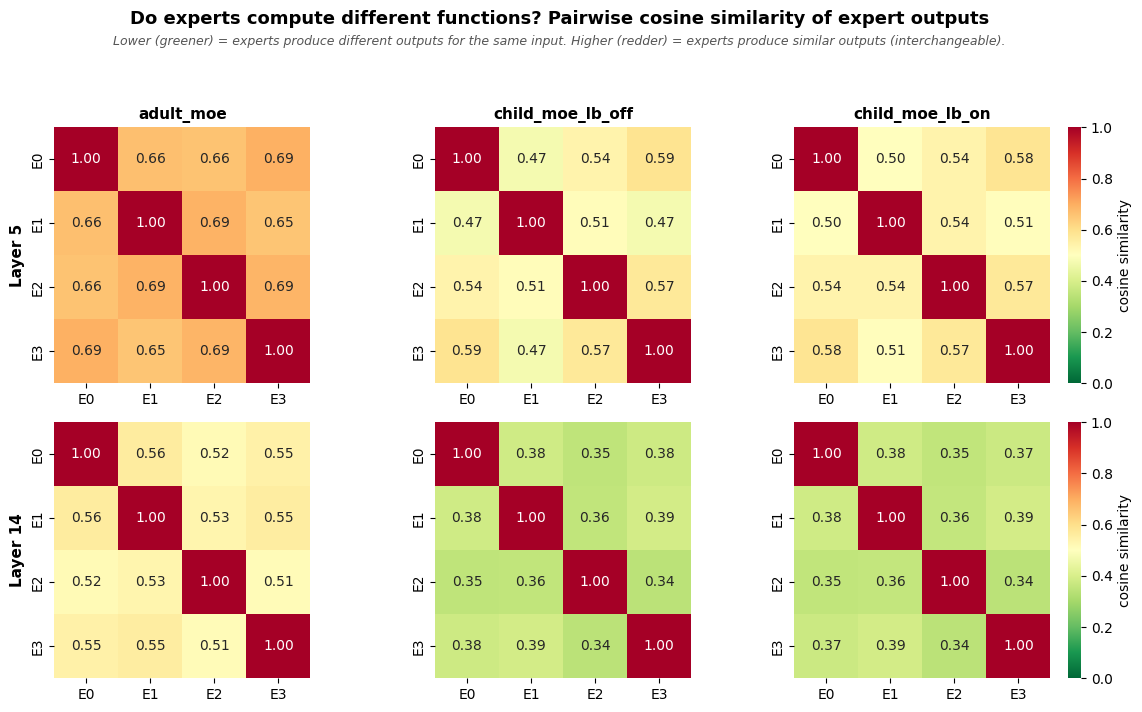


=== Connecting Part 1 routing to Part 2 expert similarity ===
adult_moe L5: child-pref=E1 (Δ=+0.15), adult-pref=E2 (Δ=-0.10), cosine(E1, E2) = 0.690
adult_moe L14: child-pref=E2 (Δ=+0.13), adult-pref=E3 (Δ=-0.14), cosine(E2, E3) = 0.514
child_moe_lb_off L5: child-pref=E3 (Δ=+0.57), adult-pref=E0 (Δ=-0.33), cosine(E3, E0) = 0.590
child_moe_lb_off L14: child-pref=E1 (Δ=+0.32), adult-pref=E3 (Δ=-0.29), cosine(E1, E3) = 0.391
child_moe_lb_on L5: child-pref=E3 (Δ=+0.34), adult-pref=E0 (Δ=-0.25), cosine(E3, E0) = 0.584
child_moe_lb_on L14: child-pref=E1 (Δ=+0.37), adult-pref=E3 (Δ=-0.22), cosine(E1, E3) = 0.387


In [80]:
# Part 2 — Functional analysis: do the experts actually do different things?
# For each (model, peak layer), force every frame through every expert
# (bypassing routing) and measure how similar their outputs are.
#
# Low similarity = experts compute genuinely different transformations
# High similarity = experts are interchangeable; routing is cosmetic

import torch
import torch.nn.functional as F
from tqdm import tqdm

PART2_MODELS = ["adult_moe", "child_moe_lb_off", "child_moe_lb_on"]
PART2_LAYERS = [5, 14]
PART2_N_UTTERANCES = 50
PART2_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PART2_AUDIO_SAMPLES = {
    "adult": TEST_MANIFESTS["adult"],
    "child": TEST_MANIFESTS["child"],
}

# ----------------------------------------------------------------------
# Step 1: gather a small balanced audio sample
# ----------------------------------------------------------------------
def gather_audio_paths(manifest_paths, n_per_group=25):
    audio_paths = []
    for group, manifest in manifest_paths.items():
        if not os.path.exists(manifest):
            print(f"Warning: {manifest} not found, skipping {group}")
            continue
        with open(manifest) as f:
            lines = [l.strip() for l in f if l.strip()]
        np.random.seed(42)
        chosen = np.random.choice(lines, size=min(n_per_group, len(lines)), replace=False)
        for line in chosen:
            data = json.loads(line)
            if "audio_filepath" in data and os.path.exists(data["audio_filepath"]):
                audio_paths.append(data["audio_filepath"])
    return audio_paths

audio_paths = gather_audio_paths(PART2_AUDIO_SAMPLES, n_per_group=PART2_N_UTTERANCES // 2)
print(f"Gathered {len(audio_paths)} audio files for expert output analysis")

# ----------------------------------------------------------------------
# Step 2: capture expert outputs by calling each expert on the layer input
# ----------------------------------------------------------------------
def capture_expert_outputs(model_path, audio_paths, layers, device="cuda"):
    """
    For each target layer:
      - Hook the MoE feed_forward block to capture its input tensor x.
      - After the forward pass, manually call each expert on x using the
        stacked w1/w2/b1/b2 tensors stored directly as parameters on the
        ConformerMoEFeedForward module.
      - Stack outputs across frames to get [n_frames, n_experts, hidden_dim].
    """
    model = nemo_asr.models.EncDecCTCModelBPE.restore_from(model_path, map_location=device)
    model.eval()

    layer_inputs = {layer: [] for layer in layers}
    hooks = []

    def make_pre_hook(layer_idx):
        def pre_hook(module, inputs):
            x = inputs[0].detach()
            layer_inputs[layer_idx].append(x.cpu())
        return pre_hook

    for layer in layers:
        target = model.encoder.layers[layer].feed_forward
        h = target.register_forward_pre_hook(make_pre_hook(layer))
        hooks.append(h)

    with torch.no_grad():
        for ap in tqdm(audio_paths, desc=f"Forward passes ({os.path.basename(model_path)})"):
            try:
                model.transcribe([ap], batch_size=1, verbose=False)
            except Exception as e:
                print(f"  Failed {ap}: {e}")

    for h in hooks:
        h.remove()

    expert_outputs = {}
    for layer in layers:
        if not layer_inputs[layer]:
            print(f"No captured inputs for layer {layer}")
            continue

        ff = model.encoder.layers[layer].feed_forward

        # Stacked expert weights: each parameter's first dim indexes the expert
        w1 = ff.w1  # [n_experts, hidden_ff, hidden_d] e.g. (4, 2048, 512)
        b1 = ff.b1  # [n_experts, hidden_ff]
        w2 = ff.w2  # [n_experts, hidden_d, hidden_ff] e.g. (4, 512, 2048)
        b2 = ff.b2  # [n_experts, hidden_d]
        activation = ff.activation

        n_experts = w1.shape[0]

        # Flatten each captured tensor to [frames, hidden_dim], then concatenate.
        # Each utterance has a different time length, so we cannot cat-then-reshape.
        flat_inputs = []
        for x in layer_inputs[layer]:
            if x.dim() == 3:
                # [B, T, D] -> [B*T, D]
                x = x.reshape(-1, x.shape[-1])
            elif x.dim() == 2:
                # already [T, D] or [N, D]
                pass
            else:
                print(f"Unexpected tensor shape {x.shape} at layer {layer}, skipping")
                continue
            flat_inputs.append(x)

        if not flat_inputs:
            print(f"No valid inputs for layer {layer} after flattening")
            continue

        all_inputs = torch.cat(flat_inputs, dim=0)  # [total_frames, D]

        # Subsample frames to keep memory and compute manageable
        max_frames = 5000
        if all_inputs.shape[0] > max_frames:
            idx = torch.randperm(all_inputs.shape[0])[:max_frames]
            all_inputs = all_inputs[idx]

        all_inputs = all_inputs.to(device)

        outputs_per_expert = []
        with torch.no_grad():
            for e in range(n_experts):
                # Forward pass for expert e, replicating ConformerMoEFeedForward's per-expert path:
                #   h = activation(x @ w1[e].T + b1[e])
                #   out = h @ w2[e].T + b2[e]
                h = torch.nn.functional.linear(all_inputs, w1[e], b1[e])
                h = activation(h)
                out = torch.nn.functional.linear(h, w2[e], b2[e])
                outputs_per_expert.append(out.cpu())

        expert_outputs[layer] = torch.stack(outputs_per_expert, dim=1)
        print(f"Layer {layer}: captured outputs shape {expert_outputs[layer].shape}")

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

    return expert_outputs

# ----------------------------------------------------------------------
# Step 3: cosine similarity between experts (averaged across frames)
# ----------------------------------------------------------------------
def expert_similarity_matrix(expert_outputs):
    """
    expert_outputs: [n_frames, n_experts, hidden_dim]
    Returns: [n_experts, n_experts] mean cosine similarity across frames
    """
    n_frames, n_experts, _ = expert_outputs.shape
    sim_per_frame = torch.zeros(n_frames, n_experts, n_experts)
    for f in range(n_frames):
        normed = F.normalize(expert_outputs[f], dim=-1)  # [n_experts, D]
        sim_per_frame[f] = normed @ normed.T
    return sim_per_frame.mean(dim=0).numpy()

# ----------------------------------------------------------------------
# Step 4: run for all models, save matrices
# ----------------------------------------------------------------------
similarity_results = {}  # {model_name: {layer: sim_matrix}}

for model_name in PART2_MODELS:
    if model_name not in MODELS:
        print(f"Skipping {model_name}: not in MODELS")
        continue
    print(f"\n=== Processing {model_name} ===")
    outputs = capture_expert_outputs(
        MODELS[model_name], audio_paths, PART2_LAYERS, device=PART2_DEVICE
    )
    similarity_results[model_name] = {}
    for layer, expert_out in outputs.items():
        sim = expert_similarity_matrix(expert_out)
        similarity_results[model_name][layer] = sim
        print(f"  Layer {layer} similarity matrix:\n{sim}")

# Persist results
np.savez(
    f"{ROUTING_CACHE_DIR}/expert_output_similarity.npz",
    **{
        f"{model}_L{layer}": sim
        for model, layers in similarity_results.items()
        for layer, sim in layers.items()
    },
)
print(f"\nSaved {ROUTING_CACHE_DIR}/expert_output_similarity.npz")

# ----------------------------------------------------------------------
# Step 5: visualise — one row per layer, one column per model
# ----------------------------------------------------------------------
fig, axes = plt.subplots(
    len(PART2_LAYERS), len(PART2_MODELS),
    figsize=(4 * len(PART2_MODELS), 3.5 * len(PART2_LAYERS)),
)
if len(PART2_LAYERS) == 1:
    axes = axes.reshape(1, -1)
if len(PART2_MODELS) == 1:
    axes = axes.reshape(-1, 1)

for r, layer in enumerate(PART2_LAYERS):
    for c, model_name in enumerate(PART2_MODELS):
        ax = axes[r, c]
        if model_name not in similarity_results or layer not in similarity_results[model_name]:
            ax.axis("off")
            ax.set_title(f"{model_name} L{layer} (no data)")
            continue
        sim = similarity_results[model_name][layer]
        n_experts = sim.shape[0]
        sns.heatmap(
            sim, ax=ax,
            cmap="RdYlGn_r", vmin=0, vmax=1, center=0.5,
            annot=True, fmt=".2f",
            xticklabels=[f"E{i}" for i in range(n_experts)],
            yticklabels=[f"E{i}" for i in range(n_experts)],
            cbar_kws={"label": "cosine similarity"} if c == len(PART2_MODELS) - 1 else None,
            cbar=(c == len(PART2_MODELS) - 1),
            square=True,
        )
        if r == 0:
            ax.set_title(model_name, fontsize=11, fontweight="bold")
        if c == 0:
            ax.set_ylabel(f"Layer {layer}", fontsize=11, fontweight="bold")

fig.suptitle(
    "Do experts compute different functions? Pairwise cosine similarity of expert outputs",
    fontsize=13, fontweight="bold", y=1.01,
)
fig.text(
    0.5, 0.96,
    "Lower (greener) = experts produce different outputs for the same input. "
    "Higher (redder) = experts produce similar outputs (interchangeable).",
    ha="center", fontsize=9, style="italic", color="#555555",
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(f"{ROUTING_CACHE_DIR}/expert_output_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------------
# Step 6: connect to Part 1 — pull the "preferred experts" per group
# ----------------------------------------------------------------------
print("\n=== Connecting Part 1 routing to Part 2 expert similarity ===")
for model_name in PART2_MODELS:
    if model_name not in similarity_results:
        continue
    df_m = df_sig[df_sig["model"] == model_name]
    for layer in PART2_LAYERS:
        df_l = df_m[df_m["layer_idx"] == layer]
        if df_l.empty:
            continue
        # Most child-preferred and most adult-preferred experts at this layer
        child_pref = df_l.sort_values("diff_child_minus_adult", ascending=False).iloc[0]
        adult_pref = df_l.sort_values("diff_child_minus_adult", ascending=True).iloc[0]
        sim = similarity_results[model_name][layer]
        e_child = int(child_pref["expert"])
        e_adult = int(adult_pref["expert"])
        cross_sim = sim[e_child, e_adult]
        print(
            f"{model_name} L{layer}: "
            f"child-pref=E{e_child} (Δ={child_pref['diff_child_minus_adult']:+.2f}), "
            f"adult-pref=E{e_adult} (Δ={adult_pref['diff_child_minus_adult']:+.2f}), "
            f"cosine(E{e_child}, E{e_adult}) = {cross_sim:.3f}"
        )

# Phase 3 - Age or Dataset specific specialization? 

In [99]:
import os
import re
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon

ROUTING_DIR = "/lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs"

MODEL_ORDER = ["adult_moe", "child_moe_lb_off", "child_moe_lb_on"]

def detect_prob_prefix(df):
    if any(c.startswith("soft_expert_") and c.endswith("_prob") for c in df.columns):
        return "soft_expert"
    if any(c.startswith("expert_") and c.endswith("_prob") for c in df.columns):
        return "expert"
    if any(c.startswith("hard_expert_") and c.endswith("_prob") for c in df.columns):
        return "hard_expert"
    raise ValueError(f"No expert probability columns found. Columns: {df.columns.tolist()}")

def get_expert_cols(df):
    prefix = detect_prob_prefix(df)
    cols = [c for c in df.columns if c.startswith(prefix + "_") and c.endswith("_prob")]

    def get_idx(c):
        m = re.search(r"_(\d+)_prob$", c)
        return int(m.group(1)) if m else 999

    return sorted(cols, key=get_idx)

def normalize_to_standard_cols(df):
    df = df.copy()
    cols = get_expert_cols(df)

    for i, old_col in enumerate(cols):
        df[f"expert_{i}_prob"] = df[old_col].astype(float)

    return df

def load_model_domain_data(model_name):
    regular_path = f"{ROUTING_DIR}/{model_name}_routing.csv"
    yodas_path = f"{ROUTING_DIR}/{model_name}_routing_yodas.csv"

    dfs = []

    if os.path.exists(regular_path):
        df = pd.read_csv(regular_path)
        df = normalize_to_standard_cols(df)
        df["model"] = model_name
        dfs.append(df)
        print(f"Loaded {regular_path}: {len(df)} rows")
    else:
        print(f"Missing regular routing file: {regular_path}")

    if os.path.exists(yodas_path):
        df_y = pd.read_csv(yodas_path)
        df_y = normalize_to_standard_cols(df_y)
        df_y["model"] = model_name
        df_y["age_group"] = "adult"
        df_y["dataset_source"] = "yodas"
        dfs.append(df_y)
        print(f"Loaded {yodas_path}: {len(df_y)} rows")
    else:
        print(f"Missing YODAS routing file: {yodas_path}")

    if not dfs:
        raise FileNotFoundError(f"No routing files found for {model_name}")

    df_all = pd.concat(dfs, ignore_index=True)
    df_all = df_all[df_all["dataset_source"].isin(["librispeech", "myst", "yodas"])]

    return df_all

def mean_probs(df):
    cols = [f"expert_{i}_prob" for i in range(4)]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expert columns: {missing}")

    p = df[cols].mean(axis=0).values.astype(float)
    total = p.sum()
    if total <= 0:
        return None

    return p / total

def jsd(p, q):
    return float(jensenshannon(p, q, base=2) ** 2)

def jsd_by_layer(df, source_a, source_b, n_layers=17):
    rows = []

    for layer in range(n_layers):
        a = df[(df["dataset_source"] == source_a) & (df["layer_idx"] == layer)]
        b = df[(df["dataset_source"] == source_b) & (df["layer_idx"] == layer)]

        if a.empty or b.empty:
            rows.append({
                "layer_idx": layer,
                "pair": f"{source_a} vs {source_b}",
                "jsd": np.nan,
                "n_a": len(a),
                "n_b": len(b),
            })
            continue

        p = mean_probs(a)
        q = mean_probs(b)

        rows.append({
            "layer_idx": layer,
            "pair": f"{source_a} vs {source_b}",
            "jsd": jsd(p, q),
            "n_a": len(a),
            "n_b": len(b),
        })

    return pd.DataFrame(rows)

pairs = [
    ("librispeech", "yodas"),
    ("librispeech", "myst"),
    ("yodas", "myst"),
]

all_domain = {}
domain_jsd_results = []

for model_name in MODEL_ORDER:
    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    df = load_model_domain_data(model_name)
    all_domain[model_name] = df

    print("Dataset counts at layer 0:")
    print(df[df["layer_idx"] == 0]["dataset_source"].value_counts())

    for a, b in pairs:
        tmp = jsd_by_layer(df, a, b)
        tmp["model"] = model_name
        domain_jsd_results.append(tmp)

domain_jsd = pd.concat(domain_jsd_results, ignore_index=True)

out_csv = f"{ROUTING_DIR}/domain_vs_age_jsd_results.csv"
domain_jsd.to_csv(out_csv, index=False)

print("\nSaved:", out_csv)
print(domain_jsd.head())


adult_moe
Loaded /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/adult_moe_routing.csv: 268413 rows
Loaded /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/adult_moe_routing_yodas.csv: 23137 rows
Dataset counts at layer 0:
dataset_source
myst           13169
librispeech     2620
yodas           1361
Name: count, dtype: int64

child_moe_lb_off
Loaded /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/child_moe_lb_off_routing.csv: 268413 rows
Loaded /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/child_moe_lb_off_routing_yodas.csv: 23137 rows
Dataset counts at layer 0:
dataset_source
myst           13169
librispeech     2620
yodas           1361
Name: count, dtype: int64

child_moe_lb_on
Loaded /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/child_moe_lb_on_routing.csv: 268413 rows
Loaded /lp-dev/amelia/

In [100]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon

ROUTING_DIR = "/lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs"

MODEL_ORDER = ["adult_moe", "child_moe_lb_off", "child_moe_lb_on"]

def detect_prob_prefix(df):
    """
    Prefer soft routing probabilities if available.
    Fall back to expert_*_prob or hard_expert_*_prob.
    """
    if any(c.startswith("soft_expert_") and c.endswith("_prob") for c in df.columns):
        return "soft_expert"
    if any(c.startswith("expert_") and c.endswith("_prob") for c in df.columns):
        return "expert"
    if any(c.startswith("hard_expert_") and c.endswith("_prob") for c in df.columns):
        return "hard_expert"
    raise ValueError(f"No expert probability columns found. Columns: {df.columns.tolist()}")

def expert_cols(df):
    prefix = detect_prob_prefix(df)
    cols = [c for c in df.columns if c.startswith(prefix + "_") and c.endswith("_prob")]

    def get_idx(c):
        m = re.search(r"_(\d+)_prob$", c)
        return int(m.group(1)) if m else 999

    return sorted(cols, key=get_idx)

def normalize_to_standard_cols(df):
    """
    Converts whichever expert probability format exists into:
    expert_0_prob, expert_1_prob, ...
    """
    df = df.copy()
    cols = expert_cols(df)

    for new_i, old_col in enumerate(cols):
        df[f"expert_{new_i}_prob"] = df[old_col].astype(float)

    return df

def load_model_domain_data(model_name):
    regular_path = f"{ROUTING_DIR}/{model_name}_routing.csv"
    yodas_path = f"{ROUTING_DIR}/{model_name}_routing_yodas.csv"

    dfs = []

    if os.path.exists(regular_path):
        df = pd.read_csv(regular_path)
        df = normalize_to_standard_cols(df)
        df["model"] = model_name

        # Expected from your normal routing extraction:
        # adult/librispeech and child/myst
        dfs.append(df)
    else:
        print(f"Missing regular routing file: {regular_path}")

    if os.path.exists(yodas_path):
        df_y = pd.read_csv(yodas_path)
        df_y = normalize_to_standard_cols(df_y)
        df_y["model"] = model_name

        # Make sure labels are correct
        df_y["age_group"] = "adult"
        df_y["dataset_source"] = "yodas"

        dfs.append(df_y)
    else:
        print(f"Missing YODAS routing file: {yodas_path}")

    if not dfs:
        raise FileNotFoundError(f"No routing files found for {model_name}")

    df_all = pd.concat(dfs, ignore_index=True)

    # Keep only the three groups needed for this analysis
    df_all = df_all[df_all["dataset_source"].isin(["librispeech", "myst", "yodas"])]

    return df_all

all_domain = {}

for model in MODEL_ORDER:
    df = load_model_domain_data(model)
    all_domain[model] = df
    print("\n", model)
    print(df[df["layer_idx"] == 0]["dataset_source"].value_counts())


 adult_moe
dataset_source
myst           13169
librispeech     2620
yodas           1361
Name: count, dtype: int64

 child_moe_lb_off
dataset_source
myst           13169
librispeech     2620
yodas           1361
Name: count, dtype: int64

 child_moe_lb_on
dataset_source
myst           13169
librispeech     2620
yodas           1361
Name: count, dtype: int64


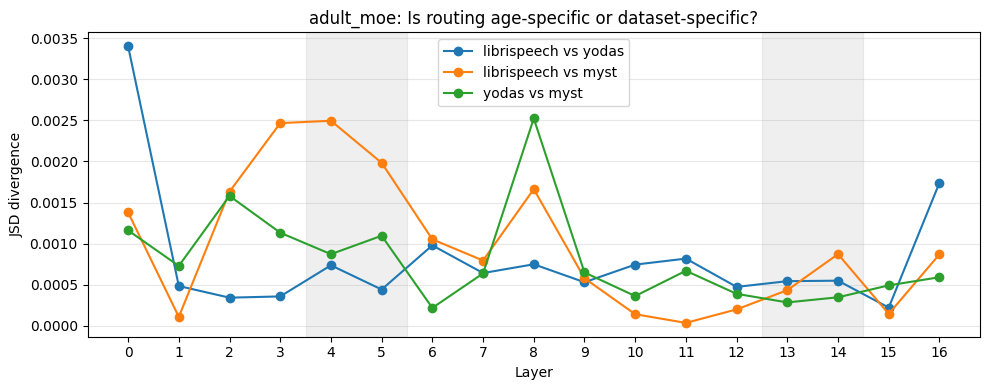

Saved /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/adult_moe_domain_vs_age_jsd.png


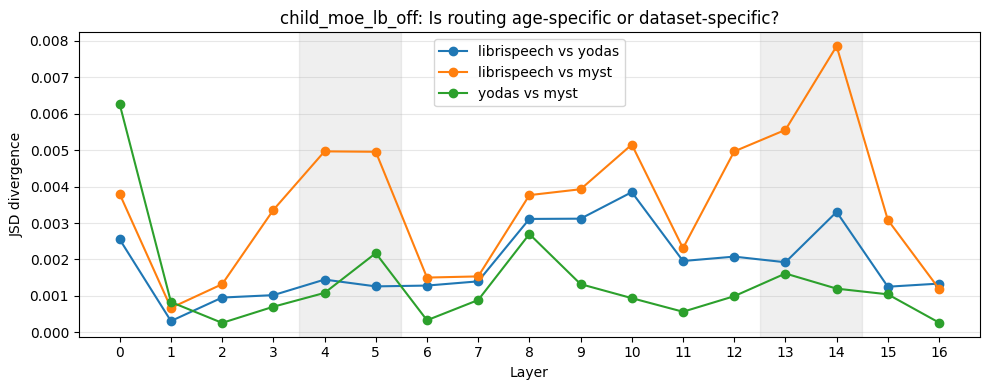

Saved /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/child_moe_lb_off_domain_vs_age_jsd.png


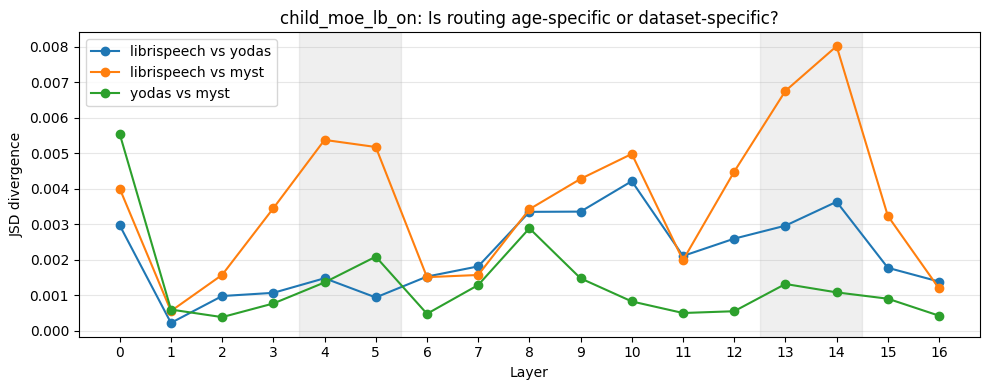

Saved /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/child_moe_lb_on_domain_vs_age_jsd.png


In [101]:
PEAK_BANDS = [(4, 5), (13, 14)]

for model_name in MODEL_ORDER:
    df_plot = domain_jsd[domain_jsd["model"] == model_name]

    fig, ax = plt.subplots(figsize=(10, 4))

    for start, end in PEAK_BANDS:
        ax.axvspan(start - 0.5, end + 0.5, color="gray", alpha=0.12)

    for pair in df_plot["pair"].unique():
        d = df_plot[df_plot["pair"] == pair].sort_values("layer_idx")
        ax.plot(d["layer_idx"], d["jsd"], marker="o", label=pair)

    ax.set_title(f"{model_name}: Is routing age-specific or dataset-specific?")
    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD divergence")
    ax.set_xticks(range(17))
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    save_path = f"{ROUTING_DIR}/{model_name}_domain_vs_age_jsd.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved {save_path}")

In [102]:
summary_rows = []

for model_name in MODEL_ORDER:
    df_m = domain_jsd[domain_jsd["model"] == model_name]

    for layer_group_name, layer_filter in {
        "all_layers": list(range(17)),
        "early_peak_L4_L5": [4, 5],
        "late_peak_L13_L14": [13, 14],
    }.items():
        df_g = df_m[df_m["layer_idx"].isin(layer_filter)]

        vals = {}
        for pair in df_g["pair"].unique():
            vals[pair] = df_g[df_g["pair"] == pair]["jsd"].mean()

        adult_domain = vals.get("librispeech vs yodas", np.nan)
        adult_child_1 = vals.get("librispeech vs myst", np.nan)
        adult_child_2 = vals.get("yodas vs myst", np.nan)
        adult_child_mean = np.nanmean([adult_child_1, adult_child_2])

        ratio = adult_child_mean / adult_domain if adult_domain > 0 else np.nan

        summary_rows.append({
            "model": model_name,
            "layer_group": layer_group_name,
            "adult_domain_jsd_librispeech_yodas": adult_domain,
            "adult_child_jsd_librispeech_myst": adult_child_1,
            "adult_child_jsd_yodas_myst": adult_child_2,
            "adult_child_mean_jsd": adult_child_mean,
            "adult_child_to_adult_domain_ratio": ratio,
        })

summary = pd.DataFrame(summary_rows)

out_summary = f"{ROUTING_DIR}/domain_vs_age_summary.csv"
summary.to_csv(out_summary, index=False)

print(f"Saved {out_summary}")
summary

Saved /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/domain_vs_age_summary.csv


,model,layer_group,adult_domain_jsd_librispeech_yodas,adult_child_jsd_librispeech_myst,adult_child_jsd_yodas_myst,adult_child_mean_jsd,adult_child_to_adult_domain_ratio
0,adult_moe,all_layers,0.000809,0.000991,0.000808,0.000900,1.111735
1,adult_moe,early_peak_L4_L5,0.000589,0.002239,0.000984,0.001611,2.733644
2,adult_moe,late_peak_L13_L14,0.000547,0.000653,0.000316,0.000485,0.887044
3,child_moe_lb_off,all_layers,0.001892,0.003523,0.001364,0.002444,1.291293
4,child_moe_lb_off,early_peak_L4_L5,0.001356,0.004959,0.001629,0.003294,2.429451
5,child_moe_lb_off,late_peak_L13_L14,0.002614,0.006701,0.001408,0.004054,1.550925
6,child_moe_lb_on,all_layers,0.002136,0.003621,0.001318,0.002469,1.155833
7,child_moe_lb_on,early_peak_L4_L5,0.001205,0.005277,0.001721,0.003499,2.903681
8,child_moe_lb_on,late_peak_L13_L14,0.003295,0.007390,0.001195,0.004293,1.302594


In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROUTING_DIR = "/lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs"
MODEL_ORDER = ["adult_moe", "child_moe_lb_off", "child_moe_lb_on"]
PEAK_BANDS = [(4, 5), (13, 14)]

def make_age_specificity_df(domain_jsd):
    rows = []

    for model_name in domain_jsd["model"].unique():
        df_m = domain_jsd[domain_jsd["model"] == model_name]

        for layer in sorted(df_m["layer_idx"].unique()):
            df_l = df_m[df_m["layer_idx"] == layer]

            vals = {
                row["pair"]: row["jsd"]
                for _, row in df_l.iterrows()
            }

            adult_domain = vals.get("librispeech vs yodas", np.nan)
            adult_child_librispeech = vals.get("librispeech vs myst", np.nan)
            adult_child_yodas = vals.get("yodas vs myst", np.nan)

            adult_child_mean = np.nanmean([
                adult_child_librispeech,
                adult_child_yodas,
            ])

            score = adult_child_mean - adult_domain
            ratio = adult_child_mean / adult_domain if adult_domain > 0 else np.nan

            if np.isnan(score):
                interpretation = "missing"
            elif score > 0:
                interpretation = "age-like"
            elif score < 0:
                interpretation = "domain-like"
            else:
                interpretation = "mixed"

            rows.append({
                "model": model_name,
                "layer_idx": layer,
                "adult_domain_jsd": adult_domain,
                "adult_child_librispeech_jsd": adult_child_librispeech,
                "adult_child_yodas_jsd": adult_child_yodas,
                "adult_child_mean_jsd": adult_child_mean,
                "age_specificity_score": score,
                "adult_child_to_domain_ratio": ratio,
                "interpretation": interpretation,
            })

    return pd.DataFrame(rows)

age_spec = make_age_specificity_df(domain_jsd)

out_csv = f"{ROUTING_DIR}/age_specificity_score_by_layer.csv"
age_spec.to_csv(out_csv, index=False)
print("Saved:", out_csv)

age_spec.head()

Saved: /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/age_specificity_score_by_layer.csv


,model,layer_idx,adult_domain_jsd,adult_child_librispeech_jsd,adult_child_yodas_jsd,adult_child_mean_jsd,age_specificity_score,adult_child_to_domain_ratio,interpretation
0,adult_moe,0,0.003401,0.001380,0.001161,0.001270,-0.002131,0.373511,domain-like
1,adult_moe,1,0.000485,0.000109,0.000729,0.000419,-0.000065,0.865067,domain-like
2,adult_moe,2,0.000343,0.001632,0.001580,0.001606,0.001263,4.681548,age-like
3,adult_moe,3,0.000358,0.002466,0.001133,0.001799,0.001441,5.024746,age-like
4,adult_moe,4,0.000737,0.002494,0.000872,0.001683,0.000946,2.284892,age-like


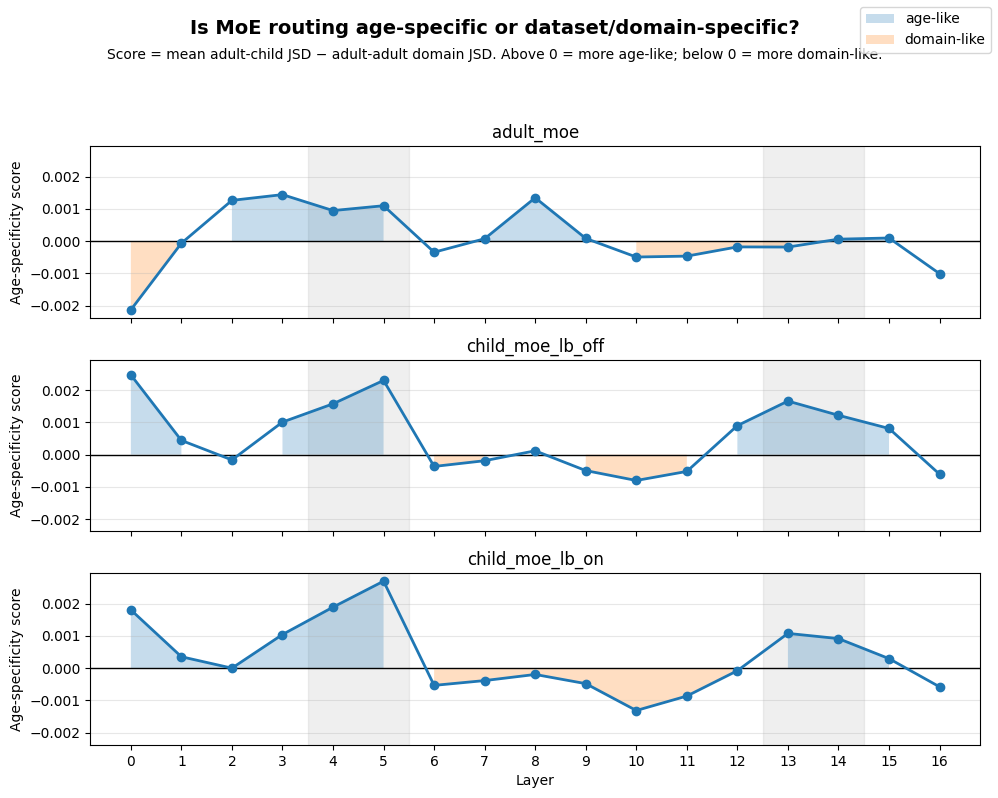

Saved: /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/age_specificity_score_by_layer.png


In [104]:
fig, axes = plt.subplots(
    len(MODEL_ORDER), 1,
    figsize=(10, 8),
    sharex=True,
    sharey=True,
)

if len(MODEL_ORDER) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODEL_ORDER):
    df_m = age_spec[age_spec["model"] == model_name].sort_values("layer_idx")

    for start, end in PEAK_BANDS:
        ax.axvspan(start - 0.5, end + 0.5, color="gray", alpha=0.12)

    ax.axhline(0, color="black", linewidth=1)

    x = df_m["layer_idx"].values
    y = df_m["age_specificity_score"].values

    ax.fill_between(
        x, y, 0,
        where=(y >= 0),
        alpha=0.25,
        label="age-like" if model_name == MODEL_ORDER[0] else None,
    )
    ax.fill_between(
        x, y, 0,
        where=(y < 0),
        alpha=0.25,
        label="domain-like" if model_name == MODEL_ORDER[0] else None,
    )

    ax.plot(x, y, marker="o", linewidth=2)

    ax.set_title(model_name)
    ax.set_ylabel("Age-specificity score")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Layer")
axes[-1].set_xticks(range(17))

fig.suptitle(
    "Is MoE routing age-specific or dataset/domain-specific?",
    fontsize=14,
    fontweight="bold",
)

fig.text(
    0.5, 0.93,
    "Score = mean adult-child JSD − adult-adult domain JSD. "
    "Above 0 = more age-like; below 0 = more domain-like.",
    ha="center",
    fontsize=10,
)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.91])

save_path = f"{ROUTING_DIR}/age_specificity_score_by_layer.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

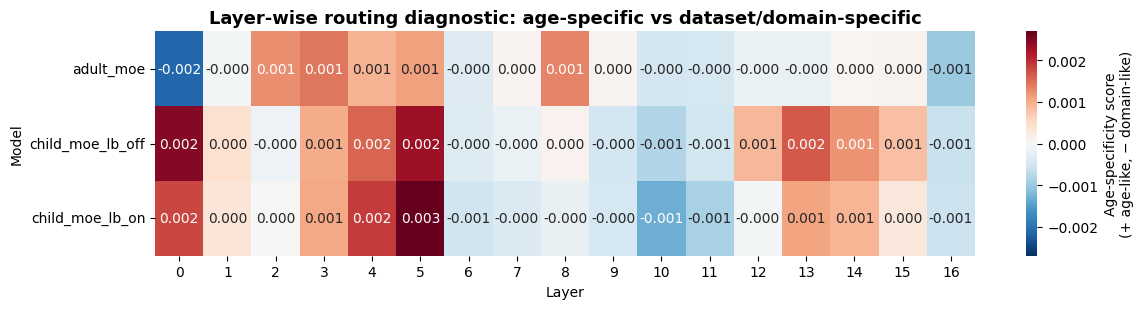

Saved: /lp-dev/amelia/inclusive-asr-moe/scripts/experiments/routing_analysis/routing_outputs/age_specificity_score_heatmap.png


In [105]:
heat = (
    age_spec
    .pivot(index="model", columns="layer_idx", values="age_specificity_score")
    .reindex(MODEL_ORDER)
)

vmax = np.nanmax(np.abs(heat.values))
vmax = max(vmax, 1e-6)

fig, ax = plt.subplots(figsize=(12, 3.2))

sns.heatmap(
    heat,
    ax=ax,
    center=0,
    vmin=-vmax,
    vmax=vmax,
    cmap="RdBu_r",
    annot=True,
    fmt=".3f",
    cbar_kws={
        "label": "Age-specificity score\n(+ age-like, − domain-like)"
    },
)

ax.set_title(
    "Layer-wise routing diagnostic: age-specific vs dataset/domain-specific",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Layer")
ax.set_ylabel("Model")

plt.tight_layout()

save_path = f"{ROUTING_DIR}/age_specificity_score_heatmap.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", save_path)